In [1]:
!pip install -q python-igraph scikit-learn ripser persim openTSNE GraphRicciCurvature

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 19.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [2]:
import torch
from torch.utils.data import Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Define the transformation pipeline:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize the image
    transforms.Lambda(lambda x: x.view(-1))           # Flatten into a 784-dim vector
])

# Load the training set (set download=True if running for the first time)
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Get indices for images where the label is 1
indices = (mnist_train.targets == 1).nonzero().squeeze()

# Create a subset containing only the '1's
mnist_train_ones = Subset(mnist_train, indices)

print(f"Total number of '1' images in the training set: {len(mnist_train_ones)}")

# Stack all 784-dim vectors from the filtered dataset
all_vectors = torch.stack([img for img, _ in mnist_train_ones])
unique_vectors = torch.unique(all_vectors, dim=0)

print(f"Total images in mnist_train_ones: {all_vectors.shape[0]}")
print(f"Unique images: {unique_vectors.shape[0]}")

if all_vectors.shape[0] == unique_vectors.shape[0]:
    print("All 784-dimensional vectors are unique.")
else:
    print("There are duplicates in the 784-dimensional vectors.")

vectors_np = unique_vectors.numpy()

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.05MB/s]


Total number of '1' images in the training set: 6742
Total images in mnist_train_ones: 6742
Unique images: 6726
There are duplicates in the 784-dimensional vectors.


In [3]:
import numpy as np


'''
not quite an r-net because there is an additional consideration that no landmark is closer to any other landmark than another parameter.
'''
def farthest_first_landmarks(vectors, max_landmarks, max_radius=None, random_state=None):
    """
    Select up to `max_landmarks` landmarks by farthest-first traversal,
    stopping early if the farthest candidate is closer than `max_radius`.

    Parameters
    ----------
    vectors : np.ndarray, shape (n_samples, n_features)
        Data points.
    max_landmarks : int
        Maximum number of landmarks to select.
    max_radius : float or None
        If the current farthest‐first distance is ≤ max_radius, stop early.
    random_state : int or np.random.Generator, optional
        Seed or generator for reproducibility.

    Returns
    -------
    landmarks : List[int]
        Indices of chosen landmarks.
    """
    n, _ = vectors.shape
    rng = np.random.default_rng(random_state)

    first = int(rng.integers(n))
    landmarks = [first]

    diffs = vectors - vectors[first]
    min_dists = np.linalg.norm(diffs, axis=1)

    for _ in range(1, max_landmarks):
        farthest_dist = min_dists.max()
        if max_radius is not None and farthest_dist < max_radius:
            print(f'Breaking because farthest_dist {farthest_dist} < max radius {max_radius}')
            print(min_dists)
            break

        next_idx = int(np.argmax(min_dists))
        landmarks.append(next_idx)

        diffs = vectors - vectors[next_idx]
        d2 = np.linalg.norm(diffs, axis=1)
        min_dists = np.minimum(min_dists, d2)

    return landmarks

max_radius = 5
landmark_idxs = farthest_first_landmarks(vectors_np, max_landmarks=100000, max_radius=max_radius, random_state=42)

# to get the actual vectors:
landmark_vectors = vectors_np[landmark_idxs]

# print("Chosen landmark indices:", landmark_idxs)
print("Their shapes:", landmark_vectors.shape)  # (10, 784) if MNIST



Breaking because farthest_dist 4.898979663848877 < max radius 5
[0.        4.472136  0.        ... 4.7958317 0.        0.       ]
Their shapes: (563, 784)


In [4]:
from sklearn.neighbors import NearestNeighbors
import igraph as ig

def build_radius_graph(X, radius=6.0):
    """
    Build an undirected radius graph on X where any two points within
    `radius` (Euclidean) are connected by an edge weighted by their distance.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Your landmark vectors (e.g. the output of farthest_first_landmarks).
    radius : float
        The maximum Euclidean distance for an edge.

    Returns
    -------
    g : igraph.Graph
        An undirected graph on n vertices.  g.es['weight'] gives each
        edge’s Euclidean length.
    """
    # find all neighbors within `radius`
    nbrs = NearestNeighbors(radius=radius, metric='euclidean').fit(X)
    distances, indices = nbrs.radius_neighbors(X, return_distance=True)

    edge_list = []
    weight_list = []
    n = X.shape[0]
    for i, (dists, neighs) in enumerate(zip(distances, indices)):
        for j, dist in zip(neighs, dists):
            # undirected: keep only one of (i,j) and (j,i), skip self
            if i < j:
                edge_list.append((i, j))
                weight_list.append(dist)

    g = ig.Graph(n=n, edges=edge_list, directed=False)
    g.es['weight'] = weight_list
    g.vs['orig_idx'] = landmark_idxs
    return g

# usage:
land_vectors = vectors_np[landmark_idxs]  # shape (k,784)
g_radius = build_radius_graph(land_vectors, radius=max_radius+1)
g_radius.vcount(), g_radius.ecount()

(563, 3128)

In [5]:
import numpy as np

def find_affected_pairs_dijkstra(D_old, dist_from_u, dist_from_v, u, v, w_uv):
    """
    Given old all-pairs distances (D_old), new Dijkstra distances from u and v after adding edge (u, v, w_uv),
    return a list of node pairs (s, t) whose shortest path is improved by the new edge.
    """
    n = len(D_old)
    affected_pairs = []

    for s in range(n):
        for t in range(n):
            if s == t:
                continue
            new_dist = min(
                dist_from_u[s] + w_uv + dist_from_v[t],
                dist_from_v[s] + w_uv + dist_from_u[t]
            )
            if new_dist < D_old[s][t]:
                affected_pairs.append((s, t))

    return affected_pairs

def find_affected_pairs_dijkstra_vectorized(D_old, dist_from_u, dist_from_v, w_uv):
    """
    Vectorized version of affected pair detection for Dijkstra updates.
    Returns array of affected (s, t) index pairs.
    """
    dist_from_u = np.asarray(dist_from_u)
    dist_from_v = np.asarray(dist_from_v)

    # Broadcast to get all-pairs distances through u-v and v-u paths
    D1 = dist_from_u[:, None] + w_uv + dist_from_v[None, :]
    D2 = dist_from_v[:, None] + w_uv + dist_from_u[None, :]
    D_new = np.minimum(D1, D2)

    # Compare to old distances
    mask = D_new < D_old
    np.fill_diagonal(mask, False)  # ignore (s, s) pairs

    affected_indices = np.argwhere(mask)
    return affected_indices  # shape (k, 2), each row is (s, t)



In [6]:
import numpy as np

def update_loads_per_pair(g, D_euc, loads, pair_paths, pair_stretch, affected_pairs):
    """
    Incrementally update edge loads for affected (i, j) node pairs.

    Parameters:
    - g: igraph Graph with 'weight' edge attribute
    - D_euc: numpy array of Euclidean distances
    - loads: numpy array of current per-edge load values
    - pair_paths: dict mapping (i,j) -> list of edge IDs for current shortest path
    - pair_stretch: dict mapping (i,j) -> current stretch value
    - affected_pairs: iterable of (i, j) tuples whose shortest path changed

    Returns:
    - loads: updated numpy array of per-edge loads
    - pair_paths: updated dict of paths
    - pair_stretch: updated dict of stretch values
    """
    for (i, j) in affected_pairs:
        if i > j:
            i, j = j, i  # ensure (i,j) key ordering

        # Remove old contribution
        old_edges = pair_paths[(i, j)]
        old_s = pair_stretch[(i, j)]
        for eid in old_edges:
            loads[eid] -= old_s

        # Compute new shortest path edges
        new_path = g.get_shortest_paths(i, to=j, weights='weight', output='epath')[0]
        # Compute new geodesic length
        new_geo = sum(g.es[e]['weight'] for e in new_path)
        # New stretch
        new_s = new_geo - D_euc[i, j]

        # Add new contribution
        for eid in new_path:
            loads[eid] += new_s

        # Update trackers
        pair_paths[(i, j)] = new_path
        pair_stretch[(i, j)] = new_s

    return loads, pair_paths, pair_stretch


In [7]:
import time
import numpy as np

# ——— Helper: initialize per-pair tracking ———
def init_pair_tracking(g, D_euc):
    n = g.vcount()
    loads = np.zeros(g.ecount())
    pair_paths = {}
    pair_stretch = {}
    for i in range(n):
        for j in range(i+1, n):
            path = g.get_shortest_paths(i, to=j, weights='weight', output='epath')[0]
            geo = sum(g.es[e]['weight'] for e in path)
            s   = geo - D_euc[i, j]
            pair_paths[(i, j)]   = path
            pair_stretch[(i, j)] = s
            for eid in path:
                loads[eid] += s
    return loads, pair_paths, pair_stretch

# ——— Per-pair incremental updater ———
def update_loads_per_pair(g, D_euc, loads, pair_paths, pair_stretch, affected_pairs):
    for (i, j) in affected_pairs:
        if i > j: i, j = j, i
        old_edges = pair_paths[(i, j)]
        old_s     = pair_stretch[(i, j)]
        # subtract old
        for eid in old_edges:
            loads[eid] -= old_s
        # recompute new path & stretch
        new_path = g.get_shortest_paths(i, to=j, weights='weight', output='epath')[0]
        new_geo  = sum(g.es[e]['weight'] for e in new_path)
        new_s    = new_geo - D_euc[i, j]
        # add new
        for eid in new_path:
            loads[eid] += new_s
        # update trackers
        pair_paths[(i, j)]   = new_path
        pair_stretch[(i, j)] = new_s
    return loads, pair_paths, pair_stretch

In [8]:
import numpy as np
import copy
import time

def find_best_edge_to_reduce_loads_topk(
    subg, loads, pair_paths, pair_stretch, D_euc,
    k=500
):
    """
    Incremental search over the TOP‐k most stretched node‐pairs
    (by geo/euc ratio) for the edge whose addition reduces total load most.
    Times each component and prints immediately.

    Returns best_pair, best_total_load, best_loads, best_paths, best_stretch.
    """
    n = subg.vcount()

    # 1) Compute current geodesic distances once
    t0 = time.time()
    D_geo = np.array(subg.distances(weights='weight'))
    t1 = time.time()
    print(f"[Timing] Computed all‐pairs geodesic distances: {t1-t0:.3f}s")

    # 2) Compute stretch ratio for all i<j
    t0 = time.time()
    iu, ju = np.triu_indices(n, k=1)
    euc = D_euc[iu, ju]
    geo = D_geo[iu, ju]
    ratio = geo / (euc + 1e-12)       # avoid div0
    # select top‐k by ratio
    top_idx = np.argpartition(-ratio, k)[:k]
    candidates = [(int(iu[idx]), int(ju[idx])) for idx in top_idx]
    t1 = time.time()
    print(f"[Timing] Selected top {k} stretched pairs: {t1-t0:.3f}s")

    # Prepare best trackers
    best_total   = loads.sum()
    best_pair    = None
    best_loads   = loads.copy()
    best_paths   = copy.deepcopy(pair_paths)
    best_stretch = copy.deepcopy(pair_stretch)

    # 3) Iterate over those top‐k candidates
    for (i, j) in candidates:
        print(f"\n-- Testing edge ({i}, {j}) --")

        # A) add edge
        tA = time.time()
        w_euc = D_euc[i, j]
        subg.add_edge(i, j, weight=w_euc)
        print(f"[Timing] Edge addition:        {time.time()-tA:.3f}s")

        # grow loads copy
        loads_copy = np.concatenate([loads, [0.0]])

        # B) SSSP from endpoints
        tB = time.time()
        dist_u = np.array(subg.distances(source=i, weights='weight'))[0]
        dist_v = np.array(subg.distances(source=j, weights='weight'))[0]
        print(f"[Timing] SSSP from endpoints:  {time.time()-tB:.3f}s")

        # C) vectorized affected‐pair detection
        tC = time.time()
        affected = find_affected_pairs_dijkstra_vectorized(
            D_old=D_geo,
            dist_from_u=dist_u,
            dist_from_v=dist_v,
            w_uv=w_euc
        )
        print(f"[Timing] Affected pairs:       {time.time()-tC:.3f}s  (#={len(affected)})")

        # D) deep‐copy state
        tD = time.time()
        paths_copy   = copy.deepcopy(pair_paths)
        stretch_copy = copy.deepcopy(pair_stretch)
        print(f"[Timing] State copy:           {time.time()-tD:.3f}s")

        # E) incremental update
        tE = time.time()
        loads_new, paths_new, stretch_new = update_loads_per_pair(
            subg, D_euc, loads_copy, paths_copy, stretch_copy, affected
        )
        print(f"[Timing] Incremental update:    {time.time()-tE:.3f}s")

        # F) evaluate improvement
        total_new = loads_new.sum()
        print(f"[Timing] Total load now = {total_new:.6f}")
        if total_new < best_total:
            best_total   = total_new
            best_pair    = (i, j)
            best_loads   = loads_new.copy()
            best_paths   = copy.deepcopy(paths_new)
            best_stretch = copy.deepcopy(stretch_new)
            print(f"[Update] New best edge = {best_pair} → load {best_total:.6f}")

        # G) remove test edge
        tG = time.time()
        subg.delete_edges([(i, j)])
        print(f"[Timing] Edge removal:         {time.time()-tG:.3f}s")

    return best_pair, best_total, best_loads, best_paths, best_stretch


In [9]:
def reset():
    comp   = g_radius.connected_components()
    subg   = comp.giant()

    orig_idxs = subg.vs['orig_idx']            # indices into vectors_np
    L      = vectors_np[orig_idxs]            # (M, 784) landmark vectors in the giant

    D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)

    # 3) Straight‐line (Euclidean) distance matrix on those same vectors
    diffs = L[:, None, :] - L[None, :, :]     # (M, M, 784)
    D_euc = np.linalg.norm(diffs, axis=2)     # (M, M)

    # 4) Extra‐flips matrix: clamp any negatives to zero
    extra_flips = np.clip(D_geo - D_euc, a_min=0, a_max=None)  # (M, M)


    M = subg.vcount()

    # 2) Prepare to loop the upper triangle
    iu, ju = np.triu_indices(M, k=1)

    # 3) Initialize edge_load for each edge in subg
    edge_load = np.zeros(subg.ecount(), dtype=float)

    # 4) Accumulate detour “flow” onto each shortest-path edge
    for i, j in zip(iu, ju):
        s = extra_flips[i, j]
        if s <= 0:
            continue
        # fetch the unique shortest path (sequence of vertex indices)
        path = subg.get_shortest_paths(i, to=j, weights='weight', mode='ALL')[0]
        # add this detour value to each edge along that path
        for u, v in zip(path[:-1], path[1:]):
            eid = subg.get_eid(u, v)   # undirected edge id
            edge_load[eid] += s

    # 5) (optional) store back on the graph
    subg.es['load'] = edge_load

    # Now `edge_load[e]` is the total “wasted‐flips” load carried by edge e.
    return subg, D_euc

In [10]:
import time
import numpy as np

subg, D_euc = reset()
# Assumes these helper functions are already defined:
# - init_pair_tracking(g, D_euc)
# - find_best_edge_to_reduce_loads_incremental(subg, loads, pair_paths, pair_stretch, D_euc, D_old, compute_stretch_loads, max_candidates)
# - update_loads_per_pair(...) is used internally by the incremental finder

# 1) Initialize once
loads, pair_paths, pair_stretch = init_pair_tracking(subg, D_euc)
max_iters = 1
threshold = 1

for it in range(1, max_iters + 1):
    print(f"\n--- Iteration {it} ---")

    # A) Report current total load
    t0 = time.time()
    total_load = loads.sum()
    print(f"[A] Total stretch load = {total_load:.6f}")
    t1 = time.time()
    print(f"    (took {t1-t0:.3f}s)")

    if total_load <= threshold:
        print("Threshold reached; stopping.")
        break

    # B) Invert loads to create inv_weight attribute (if you still need inv_weight elsewhere)
    t0 = time.time()
    M = loads.max()
    inv_w = np.clip((M + 1) - loads, a_min=1e-6, a_max=None)
    subg.es['inv_weight'] = inv_w
    t1 = time.time()
    print(f"[B] Inverted weights    (took {t1-t0:.3f}s)")

    # C–F) Brute‐force search for best edge via incremental per‐pair updates
    t0 = time.time()
    # D_old: current geodesic distances on the weighted graph
    D_old = np.array(subg.distances(weights='weight'))

    best_pair, best_total, best_loads, best_paths, best_stretch = find_best_edge_to_reduce_loads_topk(
        subg,
        loads,
        pair_paths,
        pair_stretch,
        D_euc,
        k=100
    )

    t1 = time.time()
    print(f"[C–F] Best edge {best_pair} → new total load {best_total:.6f} (search took {t1-t0:.3f}s)")

    if best_pair is None:
        print("No edge found that reduces load; stopping.")
        break

    # G) Actually add the best edge and update trackers
    i_best, j_best = best_pair
    w_euc = D_euc[i_best, j_best]
    subg.add_edge(i_best, j_best, weight=w_euc)
    # adopt the updated loads and per‐pair state:
    loads = best_loads
    pair_paths   = best_paths
    pair_stretch = best_stretch
    subg.es['load'] = loads

print("\nFinished unfolding.")


<ipython-input-9-815069cc57f2>:8: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)



--- Iteration 1 ---
[A] Total stretch load = 8104460.057788
    (took 0.000s)
[B] Inverted weights    (took 0.000s)
[Timing] Computed all‐pairs geodesic distances: 0.127s
[Timing] Selected top 100 stretched pairs: 0.017s

-- Testing edge (114, 138) --
[Timing] Edge addition:        0.000s
[Timing] SSSP from endpoints:  0.001s
[Timing] Affected pairs:       0.005s  (#=2678)
[Timing] State copy:           1.281s
[Timing] Incremental update:    1.027s
[Timing] Total load now = 7912121.902033
[Update] New best edge = (114, 138) → load 7912121.902033
[Timing] Edge removal:         0.000s

-- Testing edge (100, 138) --
[Timing] Edge addition:        0.000s
[Timing] SSSP from endpoints:  0.001s
[Timing] Affected pairs:       0.002s  (#=1564)
[Timing] State copy:           1.022s
[Timing] Incremental update:    0.593s
[Timing] Total load now = 7951344.295320
[Timing] Edge removal:         0.000s

-- Testing edge (23, 138) --
[Timing] Edge addition:        0.000s
[Timing] SSSP from endpoints: 

In [11]:
import numpy as np

import numpy as np

def init_pair_tracking_with_loads(g, D_euc):
    """
    For every unordered node-pair (i<j), compute:
     - the shortest-path 'stretch' s = geo - D_euc[i,j]
     - record the edge-path for that pair
     - accumulate s onto each edge in that path to get edge_loads

    Returns:
      loads_per_pair: np.ndarray of shape (P,) giving stretch per pair
      pair_paths: dict mapping (i,j) -> list of edge IDs
      pair_stretch: dict mapping (i,j) -> stretch value s
      edge_loads: np.ndarray of shape (g.ecount(),) giving total load per edge
    """
    n = g.vcount()
    # Estimate number of pairs P = n*(n-1)/2
    # We'll collect per-pair data in lists, then convert to arrays.
    pairs = []
    stretches = []
    pair_paths = {}
    pair_stretch = {}
    edge_loads = np.zeros(g.ecount(), dtype=float)

    for i in range(n):
        for j in range(i+1, n):
            path = g.get_shortest_paths(i, to=j, weights='weight', output='epath')[0]
            geo = sum(g.es[e]['weight'] for e in path)
            s = geo - D_euc[i, j]

            pairs.append((i, j))
            stretches.append(s)
            pair_paths[(i, j)] = path
            pair_stretch[(i, j)] = s

            for eid in path:
                edge_loads[eid] += s

    loads_per_pair = np.array(stretches, dtype=float)
    return loads_per_pair, pair_paths, pair_stretch, edge_loads



def compute_all_pairs_geo(subg):
    """
    Returns the full all-pairs geodesic distance matrix D_geo (n×n).
    """
    return np.array(subg.distances(weights='weight'))

def select_topk_stretch(D_geo, D_euc, k):
    """
    Flattens the upper triangle of D_geo and D_euc, computes geo/euc ratio,
    and returns arrays us, vs, ws for the top-k stretched candidate edges.
    """
    n = D_geo.shape[0]
    iu, ju = np.triu_indices(n, k=1)
    old_geo = D_geo[iu, ju]
    old_euc = D_euc[iu, ju] + 1e-12
    ratio   = old_geo / old_euc
    top     = np.argpartition(-ratio, k)[:k]
    us = iu[top]
    vs = ju[top]
    ws = D_euc[us, vs]
    return us, vs, ws, iu, ju, old_geo

def compute_candidate_endpoints(D_geo, us, vs, ws):
    """
    Given arrays us, vs, ws (shape k,), returns
    D_u, D_v (each k×n)—the pre-edge distances from each u and v to all nodes.
    """
    D_u = D_geo[us, :]
    D_v = D_geo[vs, :]
    return D_u, D_v

def compute_best_via(D_u, D_v, ws, iu, ju):
    """
    For each candidate c and each original pair index p,
    compute the new shortest-path length via that candidate edge,
    _using the edge exactly once_.

    Inputs:
      - D_u: (k,n) array of original distances from each u_c to every node
      - D_v: (k,n) array of original distances from each v_c to every node
      - ws : (k,) array of the new-edge weights for each candidate
      - iu, ju: each (P,) arrays of the flattened pairs

    Returns:
      best_via: (k,P) array where best_via[c,p] is
                min( D_u[c,iu[p]] + ws[c] + D_v[c,ju[p]],
                     D_v[c,iu[p]] + ws[c] + D_u[c,ju[p]] )
    """
    # shape (k,P)
    via_uv = D_u[:, iu] + ws[:, None] + D_v[:, ju]
    via_vu = D_v[:, iu] + ws[:, None] + D_u[:, ju]
    return np.minimum(via_uv, via_vu)


def compute_load_reduction(best_via, old_geo, loads_per_pair):
    """
    Computes total load reduction per candidate.
    Returns load_reduction (shape k,).
    """
    # fractional decrease times original load
    delta = (old_geo[None,:] - best_via) / old_geo[None,:] * loads_per_pair[None,:]
    improved = best_via < old_geo[None,:]
    return np.where(improved, delta, 0.0).sum(axis=1)

def compute_per_pair_delta_for_candidate(best_idx, best_via, old_geo, loads_per_pair):
    """
    Given the full best_via (k×P), old_geo (P,), and loads_per_pair (P,),
    extract the single row best_via[best_idx] and compute the per-pair
    load reduction vector delta_best (length P).
    """
    via = best_via[best_idx]                   # shape (P,)
    old  = old_geo                             # shape (P,)
    L    = loads_per_pair                      # shape (P,)
    frac = np.clip((old - via) / old, a_min=0, a_max=None)
    return L * frac                            # shape (P,)

def find_best_edge_vectorized_with_via(subg, D_euc, loads_per_pair, k=500):
    """
    Like find_best_edge_vectorized, but also returns:
      - best_via  : the (k×P) matrix of via-distances
      - old_geo   : the length-P vector of old distances
      - loads     : the length-P vector of loads_per_pair
    """
    # 1) APSP
    D_geo = np.array(subg.distances(weights='weight'))

    # 2) top-k
    us, vs, ws, iu, ju, old_geo = select_topk_stretch(D_geo, D_euc, k)

    # 3) distances to endpoints
    D_u, D_v = compute_candidate_endpoints(D_geo, us, vs, ws)

    # 4) via-edge distances
    best_via = compute_best_via(D_u, D_v, ws, iu, ju)

    # 5) load reductions
    load_reduction = compute_load_reduction(best_via, old_geo, loads_per_pair)

    # 6) pick best
    best_idx = np.argmax(load_reduction)
    best_pair = (int(us[best_idx]), int(vs[best_idx]))

    return best_pair, load_reduction[best_idx], best_idx, best_via, old_geo, us, vs, ws, iu, ju

In [12]:
# 1) Initialize once
loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)

max_iters  = 100
threshold  = 1.0
k          = 100

In [13]:
# for it in range(1, max_iters + 1):
#     print(f"\n--- Iteration {it} ---")

#     # A) Total load
#     total_load = loads.sum()
#     print(f"[A] Total stretch load = {total_load:.6f}")
#     if total_load <= threshold:
#         print("    Threshold reached; stopping.")
#         break

#     # B) Invert weights as before
#     M     = loads.max()
#     inv_w = np.clip((M + 1) - loads, a_min=1e-6, a_max=None)
#     subg.es['weight'] = inv_w

#     # C) Vectorized search _with_ via-matrix
#     t0 = time.time()
#     best_pair, reduction, best_idx, best_via, old_geo = find_best_edge_vectorized_with_via(
#         subg=subg,
#         D_euc=D_euc,
#         loads_per_pair=loads,
#         k=k
#     )
#     print(f"[C] Best edge = {best_pair} → predicted drop {reduction:.6f} (took {time.time()-t0:.3f}s)")

#     if reduction <= 0:
#         print("    No beneficial edge; stopping.")
#         break

#     # D) Actually add that edge
#     i_best, j_best = best_pair
#     w_euc = D_euc[i_best, j_best]
#     subg.add_edge(i_best, j_best, weight=w_euc)

#     # E) Compute per-pair delta for that winner and update loads
#     delta_best = compute_per_pair_delta_for_candidate(
#         best_idx= best_idx,
#         best_via= best_via,
#         old_geo=  old_geo,
#         loads_per_pair= loads
#     )
#     loads -= delta_best

#     # F) (Optional) update subg edge attribute
#     subg.es['load'] = loads

# print("\nFinished unfolding.")

In [ ]:
import time
import numpy as np

def unfold(k=100, max_iters=100, threshold=1):
    # 1) Initialize pair‐tracking
    loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)
    pairs = list(pair_paths.keys())  # list of (i,j) in same order as loads_per_pair

    loadSumsByIter = []

    for it in range(1, max_iters + 1):
        print(f"\n--- Iteration {it} ---")

        # A) Total pair‐load
        total_pair_load = loads_per_pair.sum()
        print(f"[A] Total stretch load = {total_pair_load:.6f}")
        if total_pair_load <= threshold:
            print("    Threshold reached; stopping.")
            break

        loadSumsByIter.append(total_pair_load)

        # B) Invert edge_loads → weights for geodesic computations
        M = edge_loads.max()
        inv_w = np.clip((M + 1) - edge_loads, a_min=1e-6, a_max=None)
        subg.es['weight'] = inv_w

        # C) Vectorized search over pair‐loads
        t0 = time.time()
        best_pair, reduction, best_idx, best_via, old_geo, us, vs, ws, iu, ju = find_best_edge_vectorized_with_via(
            subg=subg,
            D_euc=D_euc,
            loads_per_pair=loads_per_pair,
            k=k
        )
        elapsed = time.time() - t0
        print(f"[C] Best edge = {best_pair} → predicted drop {reduction:.6f} (took {elapsed:.3f}s)")
        if reduction <= 0:
            print("    No beneficial edge; stopping.")
            break

        # D) Add the best edge
        i_best, j_best = best_pair
        w_euc = D_euc[i_best, j_best]
        subg.add_edge(i_best, j_best, weight=w_euc)

        # E) Update loads_per_pair via delta
        delta_pair = compute_per_pair_delta_for_candidate(
            best_idx=best_idx,
            best_via=best_via,
            old_geo=old_geo,
            loads_per_pair=loads_per_pair
        )
        loads_per_pair -= delta_pair

        # F) Recompute edge_loads from updated pair-loads
        edge_loads[:] = 0.0
        for idx, (u, v) in enumerate(pairs):
            for eid in pair_paths[(u, v)]:
                edge_loads[eid] += loads_per_pair[idx]

        # G) (Optional) assign back to graph
        subg.es['load'] = edge_loads

    print("\nFinished unfolding.")
    return subg, loadSumsByIter



In [ ]:
import copy
import time
import numpy as np

def recursive_lookahead(subg, D_euc, loads_per_pair, edge_loads, pair_paths,
                        lookahead_depth, k):
    """
    Recursively explore all sequences of length `lookahead_depth`,
    returning (best_sequence, best_cumulative_drop).
    sequence is a list of (i,j) edges.
    """
    if lookahead_depth == 0:
        return [], 0.0, 0

    # Inline full-k vectorized pipeline:
    D_geo = np.array(subg.distances(weights='weight'))
    us, vs, ws, iu, ju, old_geo_all = select_topk_stretch(D_geo, D_euc, k)
    D_u, D_v = compute_candidate_endpoints(D_geo, us, vs, ws)
    best_via_all = compute_best_via(D_u, D_v, ws, iu, ju)
    load_reductions_all = compute_load_reduction(best_via_all, old_geo_all, loads_per_pair)

    best_sequence = []
    best_total_drop = -np.inf
    best_delta = -np.inf

    # Try each of the k candidates as the first move
    for c in range(k):
        i, j = us[c], vs[c]
        drop1 = load_reductions_all[c]

        # Simulate adding edge
        subg_clone = copy.deepcopy(subg)
        subg_clone.add_edge(i, j, weight=D_euc[i, j])

        # Update loads_per_pair
        delta = compute_per_pair_delta_for_candidate(c, best_via_all, old_geo_all, loads_per_pair)
        new_loads = loads_per_pair - delta

        # Update edge_loads for the clone
        new_edge_loads = np.zeros_like(edge_loads)
        for idx, (u, v) in enumerate(pair_paths):
            for eid in pair_paths[(u, v)]:
                new_edge_loads[eid] += new_loads[idx]

        # Recurse
        seq, future_drop, future_delta = recursive_lookahead(
            subg_clone, D_euc, new_loads, new_edge_loads, pair_paths,
            lookahead_depth - 1, k
        )

        total_drop = drop1 + future_drop
        if total_drop > best_total_drop:
            best_total_drop = total_drop
            best_sequence = [(i,j)] + seq
            best_delta = delta

    return best_sequence, best_total_drop, best_delta

def unfold_with_lookahead(subg, D_euc, k=100, max_iters=100, threshold=1.0, lookahead_depth=2):
    # Work on a copy so we don’t touch the caller’s graph
    g = subg.copy()
    loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(g, D_euc)
    pairs = list(pair_paths.keys())

    loadSumsByIter = []
    for it in range(1, max_iters + 1):
        print(f"\n--- Iteration {it} ---")

        # A) Total pair-load
        total_pair_load = loads_per_pair.sum()
        print(f"[A] Total stretch load = {total_pair_load:.6f}")
        if total_pair_load <= threshold:
            print("    Threshold reached; stopping.")
            break
        loadSumsByIter.append(total_pair_load)

        # B) Invert edge_loads → weights
        M = edge_loads.max()
        inv_w = np.clip((M + 1) - edge_loads, a_min=1e-6, a_max=None)
        g.es['weight'] = inv_w
        print(f"[B] Updated edge weights from loads (max load={M:.3f})")

        # C) Lookahead search
        t0 = time.time()
        best_seq, best_drop, best_delta = recursive_lookahead(
            g, D_euc, loads_per_pair, edge_loads, pair_paths,
            lookahead_depth, k
        )
        elapsed = time.time() - t0
        print(f"[C] Lookahead depth={lookahead_depth} "
              f"with predicted drop {best_drop:.6f} (took {elapsed:.3f}s)")

        i_best, j_best = best_seq[0]
        print(f"[D] Adding edge ({i_best}, {j_best})")

        # D) Actually add it
        g.add_edge(i_best, j_best, weight=D_euc[i_best, j_best])

        # E) Update loads_per_pair
        # Recompute vectorized info so we can find the index c
        # D_geo = np.array(g.distances(weights='weight'))
        # us, vs, ws, iu, ju, old_geo_all = select_topk_stretch(D_geo, D_euc, k)
        # D_u, D_v = compute_candidate_endpoints(D_geo, us, vs, ws)
        # best_via_all = compute_best_via(D_u, D_v, ws, iu, ju)
        # c = us.tolist().index(i_best)  # find the candidate index
        # delta_pair = compute_per_pair_delta_for_candidate(c, best_via_all, old_geo_all, loads_per_pair)
        # loads_per_pair -= delta_pair
        loads_per_pair -= best_delta
        print(f"[E] Applied delta for edges, load now {loads_per_pair.sum():.6f}")

        # F) Recompute edge_loads
        edge_loads[:] = 0.0
        for idx, (u, v) in enumerate(pairs):
            for eid in pair_paths[(u, v)]:
                edge_loads[eid] += loads_per_pair[idx]
        print(f"[F] Rebuilt edge loads (sum of loads_per_pair over paths)")

    print("\nFinished unfolding with lookahead.")
    return g, loadSumsByIter


In [ ]:
# Store results for different k values, using 2-step lookahead
lookaheadResults = {}
k_values = [25, 50, 75, 100]
max_iters = 100
lookahead_depth = 2

for k_val in k_values:
    print(f"\n--- Running Unfolding with lookahead for k = {k_val} ---")
    # Reset the graph and Euclidean distances for each run
    subg, D_euc = reset()

    # Run the unfolding process with 2-step lookahead
    subg_result, loadSumsByIter = unfold_with_lookahead(
        subg=subg,
        D_euc=D_euc,
        k=k_val,
        max_iters=max_iters,
        threshold=1.0,
        lookahead_depth=lookahead_depth
    )

    # Store the results
    lookaheadResults[k_val] = loadSumsByIter

# Now results[k] contains the loadSumsByIter for each k using lookahead
# Example:
# print("Load sums for k=100:", results[100])



--- Running Unfolding with lookahead for k = 25 ---


<ipython-input-9-815069cc57f2>:8: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_geo = np.array(subg.shortest_paths(weights='weight'))  # (M, M)



--- Iteration 1 ---
[A] Total stretch load = 1522752.268903
[B] Updated edge weights from loads (max load=127999.649)


KeyboardInterrupt: 

In [ ]:
import numpy as np
import time

def unfold_bruteforce(subg, D_euc, chunk_size=100, max_iters=10, threshold=1.0):
    """
    Unfold by brute-forcing all possible new edges in manageable chunks.
    chunk_size controls how many candidate edges to evaluate at once.
    """
    # Initialize pair tracking
    loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)
    pairs = list(pair_paths.keys())

    # Precompute full list of possible node-pair candidates
    n = subg.vcount()
    iu_full, ju_full = np.triu_indices(n, k=1)
    P = len(iu_full)

    loadSumsByIter = []
    for it in range(1, max_iters + 1):
        print(f"\n--- Iteration {it} ---")
        total_load = loads_per_pair.sum()
        print(f"[A] Total stretch load = {total_load:.6f}")
        if total_load <= threshold:
            break
        loadSumsByIter.append(total_load)

        # Update weights
        M = edge_loads.max()
        subg.es['weight'] = np.clip((M + 1) - edge_loads, a_min=1e-6, a_max=None)

        # Compute full geodesic distances once
        D_geo = np.array(subg.distances(weights='weight'))

        # Precompute old_geo_all for tracked pairs (for load reduction)
        old_geo_all = D_geo[iu_full, ju_full]

        # Brute-force scan
        best_drop = -1.0
        best_pair = None
        best_idx = None

        for start in range(0, P, chunk_size):
            stop = min(start + chunk_size, P)
            iu = iu_full[start:stop]
            ju = ju_full[start:stop]
            ws = D_euc[iu, ju]
            # endpoint distances arrays
            D_u = D_geo[iu]     # shape (batch, n)
            D_v = D_geo[ju]
            # compute via distances for each candidate across all tracked pairs
            via_uv = D_u[:, iu_full] + ws[:, None] + D_v[:, ju_full]
            via_vu = D_v[:, iu_full] + ws[:, None] + D_u[:, ju_full]
            batch_via = np.minimum(via_uv, via_vu)   # shape (batch, P)

            # compute load reductions: shape (batch,)
            drops = compute_load_reduction(batch_via, old_geo_all, loads_per_pair)

            local_idx = np.argmax(drops)
            if drops[local_idx] > best_drop:
                best_drop = drops[local_idx]
                best_idx = start + local_idx
                best_pair = (int(iu[local_idx]), int(ju[local_idx]))

        print(f"[C] Brute best edge = {best_pair} → drop {best_drop:.6f}")

        # Apply best edge
        i_best, j_best = best_pair
        subg.add_edge(i_best, j_best, weight=D_euc[i_best, j_best])

        # Update loads per pair using the stored batch_via for that best candidate
        # Recompute endpoint distances for best candidate
        w_uv = D_euc[i_best, j_best]
        D_u_best = D_geo[i_best]
        D_v_best = D_geo[j_best]
        via_uv = D_u_best[iu_full] + w_uv + D_v_best[ju_full]
        via_vu = D_v_best[iu_full] + w_uv + D_u_best[ju_full]
        best_via = np.minimum(via_uv, via_vu)  # shape (P,)

        # Compute per-pair delta
        delta_pair = (old_geo_all - best_via) / (old_geo_all + 1e-12) * loads_per_pair
        delta_pair = np.where(best_via < old_geo_all, delta_pair, 0.0)

        loads_per_pair -= delta_pair

        # Recompute edge loads
        edge_loads[:] = 0.0
        for idx, (u, v) in enumerate(pairs):
            for eid in pair_paths[(u, v)]:
                edge_loads[eid] += loads_per_pair[idx]

    return subg, loadSumsByIter


In [ ]:
# Reset graph
subg, D_euc = reset()

# Run brute-force unfolding (e.g. first 20 iterations)
subg_result, loadSumsByIter = unfold_bruteforce(
    subg.copy(), D_euc,
    chunk_size=100,
    max_iters=20,
    threshold=1.0
)

print(loadSumsByIter)


# --- Iteration 1 ---
# [A] Total stretch load = 1522752.268903
# [C] Brute best edge = (366, 435) → drop 110891.343635

# --- Iteration 2 ---
# [A] Total stretch load = 1411860.925268
# [C] Brute best edge = (334, 410) → drop 68175.453167

# --- Iteration 3 ---
# [A] Total stretch load = 1343685.472101
# [C] Brute best edge = (142, 435) → drop 56787.897919

# --- Iteration 4 ---
# [A] Total stretch load = 1286897.574182
# [C] Brute best edge = (366, 435) → drop 45812.714441

# --- Iteration 5 ---
# [A] Total stretch load = 1241084.859741
# [C] Brute best edge = (289, 445) → drop 40420.494196

# --- Iteration 6 ---
# [A] Total stretch load = 1200664.365545
# [C] Brute best edge = (163, 410) → drop 36427.892811


In [ ]:
# prompt: subg, D_euc = reset()
# subg, loadSumsByIter = unfold(k=100, max_iters=100)
# run this but run like different versions with a list and save the loadSumsByIter for each output. so like k=25, 50, 75, 100 and max_iters = 100 for all

# Store results for different k values
results = {}
# k_values = [25, 50, 75, 100, 200, 300, 400, 500]
k_values = [25, 200, 500]
max_iters = 100

for k_val in k_values:
    print(f"\n--- Running Unfolding for k = {k_val} ---")
    # Reset the graph and Euclidean distances for each run
    subg, D_euc = reset()

    # Run the unfolding process with the current k
    subg_result, loadSumsByIter = unfold(k=k_val, max_iters=max_iters)

    # Store the results
    results[k_val] = loadSumsByIter

# You can now access the loadSumsByIter for each k value from the 'results' dictionary
# Example: print the load sums for k=100
# print("Load sums for k=100:", results[100])

In [ ]:
subg, D_euc = reset()

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'results' dict exists: mapping k -> list of load sums by iteration
# E.g., results = {25: [...], 50: [...], 75: [...], 100: [...]}

plt.figure()
for k, loads in sorted(results.items()):
    # Convert to percentage relative to the first iteration
    baseline = loads[0]
    pct = [100 * l / baseline for l in loads]
    plt.plot(pct, label=f'k={k}')

plt.xlabel('Iteration')
plt.ylabel('Load (% of initial)')
plt.title('Load Reduction Over Iterations for Different k Values')
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# Make sure subg, D_euc, and loads_per_pair are defined in the session
D_geo = np.array(subg.distances(weights='weight'))
loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)

# Choose a max k to iterate over (one by one)
max_k = 2000  # adjust as needed, but be wary of performance

results = []
for k in tqdm(range(1, max_k + 1, 50)):
    us, vs, ws, iu, ju, old_geo = select_topk_stretch(D_geo, D_euc, k)
    D_u, D_v = compute_candidate_endpoints(D_geo, us, vs, ws)
    best_via = compute_best_via(D_u, D_v, ws, iu, ju)
    load_reduction = compute_load_reduction(best_via, old_geo, loads_per_pair)

    idx = int(np.argmax(load_reduction))
    results.append({
        'k': k,
        'best_pair': f"({int(us[idx])}, {int(vs[idx])})",
        'predicted_drop': load_reduction[idx]
    })

df = pd.DataFrame(results)


In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' is a pandas DataFrame with columns 'k' and 'predicted_drop'
# e.g., df = pd.DataFrame(results) where results is a list of dicts with keys 'k' and 'predicted_drop'

plt.figure()
plt.bar(df['k'], df['predicted_drop'])
plt.xlabel('k (number of top-stretch candidates)')
plt.ylabel('Predicted Load Reduction')
plt.title('Best Edge Predicted Load Drop vs. k')
plt.xticks(df['k'])
plt.show()


In [ ]:
import numpy as np

def compute_fiedler_vector(subg):
    """
    Compute the Fiedler (second-smallest) eigenvector of the graph Laplacian for igraph graph `subg`.
    Returns:
      - v2: numpy array of length n, the Fiedler vector.
    """
    # 1) Build adjacency matrix A
    A = np.array(subg.get_adjacency().data, dtype=float)
    # 2) Degree matrix D
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    # 3) Laplacian L = D - A
    L = D - A
    # 4) Compute eigenvalues/eigenvectors
    # Since L is symmetric, use eigh
    vals, vecs = np.linalg.eigh(L)
    # 5) Sort eigenvalues in ascending order
    idx = np.argsort(vals)
    # 6) The Fiedler vector is the eigenvector corresponding to the second smallest eigenvalue
    fiedler_idx = idx[1]
    v2 = vecs[:, fiedler_idx]
    return v2

# Example usage:
v2 = compute_fiedler_vector(subg)
print("First few entries of the Fiedler vector:", v2[:10])


First few entries of the Fiedler vector: [ 0.00735379  0.01841793 -0.00240274 -0.00197717 -0.06379387 -0.00155191
  0.00644616 -0.00297531  0.01827864  0.01160838]


In [ ]:
import numpy as np

# 1) Compute Fiedler vector
v2 = compute_fiedler_vector(subg)

# 2) Find the pair of nodes maximizing |v2[u] - v2[v]|
u = int(np.argmax(v2))
v = int(np.argmin(v2))

print(f"Chosen endpoints by Fiedler gap: ({u}, {v})")

# 3) Prepare data for load-reduction computation on tracked pairs
loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)
pairs = list(pair_paths.keys())
P_tr = len(pairs)

# Build flattened tracked indices
iu_tr = np.array([i for (i, j) in pairs], dtype=int)
ju_tr = np.array([j for (i, j) in pairs], dtype=int)

# 4) Compute original geodesic distances
D_geo = np.array(subg.distances(weights='weight'))
old_geo_tr = D_geo[iu_tr, ju_tr]

# 5) Compute via-distances for the new edge (u,v)
w_uv = D_euc[u, v]
D_u = D_geo[u]  # distances from u to all nodes
D_v = D_geo[v]  # distances from v to all nodes

via_uv = D_u[iu_tr] + w_uv + D_v[ju_tr]
via_vu = D_v[iu_tr] + w_uv + D_u[ju_tr]
best_via = np.minimum(via_uv, via_vu)

# 6) Compute per-pair delta and total load reduction
frac = np.clip((old_geo_tr - best_via) / old_geo_tr, a_min=0, a_max=None)
delta_pair = loads_per_pair * frac
predicted_drop = delta_pair.sum()

print(f"Predicted total load reduction by adding edge ({u}, {v}): {predicted_drop:.6f}")


Chosen endpoints by Fiedler gap: (138, 100)
Predicted total load reduction by adding edge (138, 100): 7086.451488


In [ ]:
import numpy as np

# Assume subg, D_euc are already defined.

# 1) Compute a clustering assignments array using a linear-time method
# For example, label propagation (approximately O(m))
membership = np.array(subg.community_label_propagation(weights=subg.es['weight']).membership)

# 2) Precompute full upper-triangle indices once
n = subg.vcount()
iu, ju = np.triu_indices(n, k=1)

# 3) Filter pairs that are in different clusters
diff_cluster_mask = membership[iu] != membership[ju]
iu_diff = iu[diff_cluster_mask]
ju_diff = ju[diff_cluster_mask]

# 4) Compute stretch ratio for these inter-cluster pairs
old_geo = np.array(subg.distances(weights='weight'))  # full APSP if not cached
old_geo_pairs = old_geo[iu_diff, ju_diff]
old_euc_pairs = D_euc[iu_diff, ju_diff] + 1e-12
stretch_ratio = old_geo_pairs / old_euc_pairs

# 5) Pick top-k by stretch among inter-cluster edges
k = 100
top_idx = np.argpartition(-stretch_ratio, k)[:k]
us = iu_diff[top_idx]
vs = ju_diff[top_idx]

# Now (us, vs) are your k most stretched inter-cluster candidate edges
print("Top-k inter-cluster candidates:", list(zip(us, vs)))


Top-k inter-cluster candidates: [(np.int64(114), np.int64(138)), (np.int64(100), np.int64(138)), (np.int64(23), np.int64(138)), (np.int64(138), np.int64(319)), (np.int64(138), np.int64(216)), (np.int64(138), np.int64(212)), (np.int64(32), np.int64(138)), (np.int64(138), np.int64(447)), (np.int64(8), np.int64(100)), (np.int64(8), np.int64(23)), (np.int64(100), np.int64(363)), (np.int64(8), np.int64(114)), (np.int64(100), np.int64(341)), (np.int64(138), np.int64(317)), (np.int64(138), np.int64(360)), (np.int64(100), np.int64(191)), (np.int64(138), np.int64(139)), (np.int64(100), np.int64(206)), (np.int64(23), np.int64(341)), (np.int64(137), np.int64(138)), (np.int64(12), np.int64(138)), (np.int64(100), np.int64(303)), (np.int64(23), np.int64(363)), (np.int64(100), np.int64(119)), (np.int64(23), np.int64(191)), (np.int64(23), np.int64(206)), (np.int64(138), np.int64(205)), (np.int64(8), np.int64(216)), (np.int64(100), np.int64(367)), (np.int64(23), np.int64(303)), (np.int64(44), np.int64(

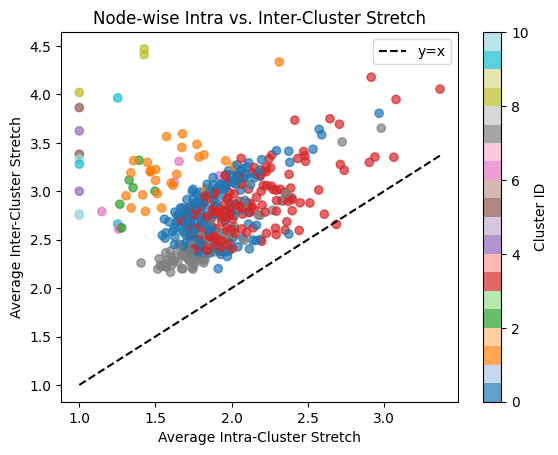

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume subg, D_euc, and membership are defined in the environment
# membership: array of length n, cluster label per node

# Compute current geodesic distances
D_geo = np.array(subg.distances(weights='weight'))

n = subg.vcount()
eps = 1e-12

avg_intra = np.zeros(n)
avg_inter = np.zeros(n)

for i in range(n):
    same = np.where((membership == membership[i]) & (np.arange(n) != i))[0]
    diff = np.where(membership != membership[i])[0]
    # Compute stretch ratios
    ratios = D_geo[i] / (D_euc[i] + eps)
    avg_intra[i] = ratios[same].mean() if same.size > 0 else np.nan
    avg_inter[i] = ratios[diff].mean() if diff.size > 0 else np.nan

# Scatter plot
plt.figure()
scatter = plt.scatter(avg_intra, avg_inter, c=membership, cmap='tab20', alpha=0.7)
plt.plot([avg_intra.min(), avg_intra.max()],
         [avg_intra.min(), avg_intra.max()], 'k--', label='y=x')
plt.xlabel('Average Intra-Cluster Stretch')
plt.ylabel('Average Inter-Cluster Stretch')
plt.title('Node-wise Intra vs. Inter-Cluster Stretch')
plt.legend()
plt.colorbar(scatter, label='Cluster ID')
plt.show()


In [ ]:
def in_same_cluster(u, v, membership):
    """
    Returns True if nodes u and v share the same cluster,
    False otherwise.
    """
    return membership[u] == membership[v]

# Example:
u, v = 366, 435
if in_same_cluster(u, v, membership):
    print(f"Nodes {u} and {v} are in the *same* cluster (#{membership[u]}).")
else:
    print(f"Nodes {u} and {v} are in *different* clusters ({membership[u]} vs {membership[v]}).")


Nodes 366 and 435 are in *different* clusters (1 vs 3).


In [ ]:
import numpy as np

# Compute Fiedler vector
v2 = compute_fiedler_vector(subg)

# Flatten all candidate pairs
n = subg.vcount()
iu, ju = np.triu_indices(n, k=1)

# Compute Fiedler gap for each candidate
gaps = (v2[iu] - v2[ju])**2

# Sort candidates by descending gap
sorted_idx = np.argsort(-gaps)  # descending
us_sorted = iu[sorted_idx]
vs_sorted = ju[sorted_idx]

# Function to get rank of a given pair (u,v)
def fiedler_rank(u, v):
    # ensure u<v
    if u > v:
        u, v = v, u
    # find match
    matches = np.where((us_sorted == u) & (vs_sorted == v))[0]
    if len(matches) == 0:
        return None
    return int(matches[0]) + 1  # rank starting at 1

# Example nodes
u_query, v_query = 366, 435  # replace with your nodes

rank = fiedler_rank(u_query, v_query)
if rank:
    print(f"Edge ({u_query},{v_query}) is ranked #{rank} by Fiedler-gap efficiency")
else:
    print(f"Edge ({u_query},{v_query}) is not in the candidate list (should not happen).")


Edge (366,435) is ranked #15713 by Fiedler-gap efficiency


In [ ]:
import numpy as np

# Nodes of interest
u, v = 366, 435

# 1) Compute node betweenness centrality for all nodes
node_btw = subg.betweenness()

# 2) Extract the values for u and v
u_btw = node_btw[u]
v_btw = node_btw[v]

# 3) Compute ranks (1 = highest betweenness)
sorted_nodes = np.argsort(-np.array(node_btw))
u_rank = int(np.where(sorted_nodes == u)[0][0]) + 1
v_rank = int(np.where(sorted_nodes == v)[0][0]) + 1

# 4) Print results
print(f"Node {u}: betweenness = {u_btw:.6f}, rank = #{u_rank} of {len(node_btw)}")
print(f"Node {v}: betweenness = {v_btw:.6f}, rank = #{v_rank} of {len(node_btw)}")


Node 366: betweenness = 1791.225486, rank = #56 of 454
Node 435: betweenness = 2368.738489, rank = #35 of 454


In [ ]:
import numpy as np

# Nodes of interest
u, v = 366, 435
u, v = min(u, v), max(u, v)

# Step 1: Check if edge exists
existing_edges = {(min(e.source, e.target), max(e.source, e.target)) for e in subg.es}
edge_exists = (u, v) in existing_edges

if edge_exists:
    print(f"Edge ({u}, {v}) already exists.")
else:
    # Step 2: Temporarily add edge
    subg.add_edge(u, v)
    eid = subg.get_eid(u, v)

    # Step 3: Edge betweenness
    edge_btw = subg.edge_betweenness()
    e_btw = edge_btw[eid]
    edge_rank = np.argsort(-np.array(edge_btw)).tolist().index(eid) + 1

    # Step 4: Node betweenness
    node_btw = subg.betweenness()
    u_btw = node_btw[u]
    v_btw = node_btw[v]
    u_rank = np.argsort(-np.array(node_btw)).tolist().index(u) + 1
    v_rank = np.argsort(-np.array(node_btw)).tolist().index(v) + 1

    # Step 5: Remove the edge again
    subg.delete_edges([(u, v)])

    # Print results
    print(f"Temporary edge added: ({u}, {v})")
    print(f"Edge betweenness: {e_btw:.2f}")
    print(f"Edge rank: #{edge_rank} of {len(edge_btw)}")
    print(f"Node {u}: betweenness = {u_btw:.2f}, rank = #{u_rank} of {len(node_btw)}")
    print(f"Node {v}: betweenness = {v_btw:.2f}, rank = #{v_rank} of {len(node_btw)}")


Temporary edge added: (366, 435)
Edge betweenness: 16911.95
Edge rank: #1 of 3118
Node 366: betweenness = 17608.41, rank = #2 of 454
Node 435: betweenness = 18328.67, rank = #1 of 454


In [ ]:
import numpy as np

# 1) Choose a source node 's'
s = 366  # replace with your node of interest, e.g., 366

# 2) Compute shortest paths from s to every other node
#    Returns list of node-index lists
vpaths = subg.get_shortest_paths(s, to=list(range(subg.vcount())),
                                 weights='weight', output='vpath')

# 3) Build a boolean matrix M of shape (n_targets, n_nodes)
#    M[t, i] = True if node i lies on the path from s to t
n = subg.vcount()
M = np.zeros((n, n), dtype=bool)
for t, path in enumerate(vpaths):
    # mark each node in the path
    for node in path:
        M[t, node] = True

# 4) Count appearances: how many s→* paths pass through each node?
appearances = M.sum(axis=0)  # length n

# 5) Normalize by number of targets to get fraction
fractional_appear = appearances / (n - 1)

# Display top nodes by appearance count
top_k = 10
idx_sorted = np.argsort(-appearances)[:top_k]
print(f"Top-{top_k} nodes on shortest paths from {s}:")
for rank, node in enumerate(idx_sorted, start=1):
    print(f"#{rank}: node {node} appears in {appearances[node]} paths "
          f"({fractional_appear[node]*100:.1f}% of all destinations)")


Top-10 nodes on shortest paths from 366:
#1: node 366 appears in 454 paths (100.2% of all destinations)
#2: node 128 appears in 220 paths (48.6% of all destinations)
#3: node 344 appears in 152 paths (33.6% of all destinations)
#4: node 347 appears in 89 paths (19.6% of all destinations)
#5: node 234 appears in 76 paths (16.8% of all destinations)
#6: node 410 appears in 76 paths (16.8% of all destinations)
#7: node 211 appears in 72 paths (15.9% of all destinations)
#8: node 415 appears in 58 paths (12.8% of all destinations)
#9: node 429 appears in 49 paths (10.8% of all destinations)
#10: node 428 appears in 46 paths (10.2% of all destinations)


In [ ]:
# prompt: do node betweenness for subg and print out top 10

# Assuming 'subg' is your igraph graph object

# Compute node betweenness centrality for all nodes
node_btw = subg.betweenness()

# Get original indices if you stored them
# orig_node_indices = subg.vs['orig_idx'] # uncomment if you added this attribute

# Combine betweenness values with node indices
betweenness_values = [(i, btw) for i, btw in enumerate(node_btw)]

# Sort by betweenness in descending order
sorted_betweenness = sorted(betweenness_values, key=lambda item: item[1], reverse=True)

# Print the top 10 nodes by betweenness centrality
print("Top 10 Nodes by Betweenness Centrality:")
for rank, (node_idx, btw_value) in enumerate(sorted_betweenness[:10], start=1):
  # If you stored original indices, you might want to print those too:
  # print(f"#{rank}: Graph Node {node_idx} (Original Index {orig_node_indices[node_idx]}) Betweenness = {btw_value:.4f}")
  print(f"#{rank}: Node {node_idx} Betweenness = {btw_value:.4f}")

Top 10 Nodes by Betweenness Centrality:
#1: Node 163 Betweenness = 9302.7329
#2: Node 400 Betweenness = 6746.0900
#3: Node 142 Betweenness = 6276.3496
#4: Node 90 Betweenness = 5424.2303
#5: Node 0 Betweenness = 5155.4508
#6: Node 225 Betweenness = 5008.6171
#7: Node 235 Betweenness = 4878.9836
#8: Node 289 Betweenness = 4509.5522
#9: Node 311 Betweenness = 3567.8599
#10: Node 310 Betweenness = 3519.4426


In [ ]:
# prompt: do node betweenness for subg print top 10 but only list nodes that arent connected to any other node in to p10

# Get the top 10 nodes by betweenness centrality
top10_nodes = [node_idx for node_idx, btw_value in sorted_betweenness[:10]]

print("\nTop 10 nodes by betweenness centrality:", top10_nodes)

# Check connectivity within the top 10 nodes
connected_within_top10 = {}
for i in range(len(top10_nodes)):
  u = top10_nodes[i]
  connected_within_top10[u] = False
  for j in range(i + 1, len(top10_nodes)):
    v = top10_nodes[j]
    if subg.are_connected(u, v):
      connected_within_top10[u] = True
      connected_within_top10[v] = True

# Find nodes in the top 10 that are not connected to any other node in the top 10
isolated_top10_nodes = [node for node, is_connected in connected_within_top10.items() if not is_connected]

print("\nNodes in the top 10 not connected to any other node in the top 10:")
if isolated_top10_nodes:
  for node in isolated_top10_nodes:
    print(f"- Node {node}")
else:
  print("All nodes in the top 10 are connected to at least one other node in the top 10.")


Top 10 nodes by betweenness centrality: [163, 400, 142, 90, 0, 225, 235, 289, 311, 310]

Nodes in the top 10 not connected to any other node in the top 10:
- Node 310
- Node 311
- Node 235
- Node 289


<ipython-input-28-8f3eaed08d60>:15: DeprecationWarning: Graph.are_connected() is deprecated; use Graph.are_adjacent() instead
  if subg.are_connected(u, v):


In [ ]:
import numpy as np

def compute_candidate_edge_drop(subg, D_euc, u, v, loads_per_pair):
    """
    Compute the total stretch-load reduction if edge (u, v) were added.

    Inputs:
      - subg: igraph Graph with current 'weight' attributes
      - D_euc: (n, n) array of Euclidean distances
      - u, v: candidate node indices (u < v)
      - loads_per_pair: (P,) array of current stretch-load per tracked pair
                         P = n*(n-1)/2, same order as iu, ju below

    Returns:
      - total_drop: scalar, sum of load reductions across all pairs
      - num_improved: count of pairs whose distance would decrease
    """
    n = subg.vcount()
    # 1) All-pairs geodesic distances
    D_geo = np.array(subg.distances(weights='weight'))

    # 2) Flatten upper triangle indices
    iu, ju = np.triu_indices(n, k=1)

    # 3) Original distances
    old_geo = D_geo[iu, ju]

    # 4) Candidate edge weight
    w_uv = D_euc[u, v]

    # 5) Distances via the new edge
    du = D_geo[u]    # shape (n,)
    dv = D_geo[v]
    via_uv = du[iu] + w_uv + dv[ju]
    via_vu = dv[iu] + w_uv + du[ju]
    best_via = np.minimum(via_uv, via_vu)

    # 6) Compute load reductions per pair
    # fractional improvement * load
    frac = np.clip((old_geo - best_via) / (old_geo + 1e-12), a_min=0, a_max=None)
    delta = loads_per_pair * frac

    total_drop = delta.sum()
    num_improved = np.count_nonzero(best_via < old_geo)
    return total_drop, num_improved

# Example usage:

# 1) Initialize pair tracking
loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)

# 2) Specify candidate nodes
u, v = 142, 225
u, v = min(u, v), max(u, v)

# 3) Compute predicted drop
drop, affected_pairs = compute_candidate_edge_drop(subg, D_euc, u, v, loads_per_pair)

print(f"Predicted total load reduction for edge ({u},{v}): {drop:.6f}")
print(f"Number of affected node-pairs: {affected_pairs}")


Predicted total load reduction for edge (142,225): 485.847479
Number of affected node-pairs: 224


In [ ]:
import numpy as np

def topk_cooccurrence(subg, s, k=10):
    """
    Identify the top-k missing edges whose endpoints co-occur
    most frequently on shortest paths from source s to all targets.

    Returns arrays us, vs, scores of length k.
    """
    n = subg.vcount()
    # 1) Compute shortest-path node lists from s to every node
    vpaths = subg.get_shortest_paths(s,
                                     to=list(range(n)),
                                     weights='weight',
                                     output='vpath')

    # 2) Build incidence matrix M (n_targets x n_nodes)
    M = np.zeros((n, n), dtype=bool)
    for t, path in enumerate(vpaths):
        for node in path:
            M[t, node] = True

    # 3) Co-occurrence matrix C = M^T * M
    C = M.T.dot(M).astype(int)  # ensure integer dtype

    # 4) Mask out existing edges and self-pairs
    A = np.array(subg.get_adjacency().data, dtype=int)
    A_bool = A.astype(bool)
    mask = ~A_bool & ~np.eye(n, dtype=bool)
    # Use where to preserve integers
    C_masked = np.where(mask, C, 0)

    # 5) Flatten upper triangle and pick top-k
    iu, ju = np.triu_indices(n, k=1)
    scores = C_masked[iu, ju]  # integer array
    if k < scores.size:
        top_idx = np.argpartition(-scores, k)[:k]
    else:
        top_idx = np.argsort(-scores)

    us = iu[top_idx]
    vs = ju[top_idx]
    sc = scores[top_idx]

    # 6) Sort the k candidates by descending score
    order = np.argsort(-sc)
    return us[order], vs[order], sc[order]

# Example usage:
# Choose a source node, e.g., s = 0 (or any node of interest)
s = 366
k = 10

us, vs, sc = topk_cooccurrence(subg, s, k)

print(f"Top {k} co-occurring missing edges for source {s}:")
for rank, (u, v, score) in enumerate(zip(us, vs, sc), start=1):
    print(f"#{rank}: edge ({u}, {v}) with co-occurrence score = {score}")


Top 10 co-occurring missing edges for source 366:
#1: edge (5, 142) with co-occurrence score = 1
#2: edge (5, 211) with co-occurrence score = 1
#3: edge (5, 250) with co-occurrence score = 1
#4: edge (5, 366) with co-occurrence score = 1
#5: edge (5, 418) with co-occurrence score = 1
#6: edge (5, 415) with co-occurrence score = 1
#7: edge (6, 171) with co-occurrence score = 1
#8: edge (6, 211) with co-occurrence score = 1
#9: edge (6, 366) with co-occurrence score = 1
#10: edge (6, 408) with co-occurrence score = 1


In [ ]:
# prompt: check if edge 4, 302 exists in sub

u_query, v_query = 4, 302  # Replace with your node indices

# Ensure u <= v for consistent indexing
u_query, v_query = min(u_query, v_query), max(u_query, v_query)

# Check if the edge exists in the graph `subg`
# igraph's `get_eid` returns -1 if the edge does not exist
# We need to be careful as `get_eid` expects source and target,
# but for undirected graph it finds it regardless of order.
# A simpler check is to use `subg.are_connected(u, v)`
edge_exists = subg.are_connected(u_query, v_query)

if edge_exists:
    print(f"Edge ({u_query}, {v_query}) exists in the graph 'subg'.")
else:
    print(f"Edge ({u_query}, {v_query}) does not exist in the graph 'subg'.")



Edge (4, 302) does not exist in the graph 'subg'.


<ipython-input-31-057591e9a3f0>:13: DeprecationWarning: Graph.are_connected() is deprecated; use Graph.are_adjacent() instead
  edge_exists = subg.are_connected(u_query, v_query)


In [ ]:
# 1) Initialize pair tracking
loads_per_pair, pair_paths, pair_stretch, edge_loads = init_pair_tracking_with_loads(subg, D_euc)

# 2) Specify candidate nodes
u, v = 4,302
u, v = min(u, v), max(u, v)

# 3) Compute predicted drop
drop, affected_pairs = compute_candidate_edge_drop(subg, D_euc, u, v, loads_per_pair)

print(f"Predicted total load reduction for edge ({u},{v}): {drop:.6f}")
print(f"Number of affected node-pairs: {affected_pairs}")


Predicted total load reduction for edge (4,302): 439.768989
Number of affected node-pairs: 238


In [ ]:
# 2) Specify candidate nodes
u, v = 4,302
u, v = min(u, v), max(u, v)

# 3) Compute predicted drop
drop, affected_pairs = compute_candidate_edge_drop(subg, D_euc, u, v, loads_per_pair)

print(f"Predicted total load reduction for edge ({u},{v}): {drop:.6f}")
print(f"Number of affected node-pairs: {affected_pairs}")

Predicted total load reduction for edge (4,302): 439.768989
Number of affected node-pairs: 238


In [ ]:
import numpy as np

def topk_source_shortcut(subg, s, k=10):
    """
    Identify the top-k nodes 'v' (not currently connected to source s)
    that appear most frequently on shortest paths from s to all other targets.

    Returns arrays vs, scores of length k.
    """
    n = subg.vcount()
    # 1) Shortest-path node lists from s to every node
    vpaths = subg.get_shortest_paths(s,
                                     to=list(range(n)),
                                     weights='weight',
                                     output='vpath')

    # 2) Count appearances of each node on s→t paths
    appearances = np.zeros(n, dtype=int)
    for path in vpaths:
        for node in path:
            appearances[node] += 1
    # We exclude the source itself
    appearances[s] = 0

    # 3) Mask out nodes already adjacent to s
    neighbors = set(subg.neighbors(s))
    mask = np.ones(n, dtype=bool)
    mask[s] = False
    for nbr in neighbors:
        mask[nbr] = False

    # 4) Apply mask
    scores = appearances * mask

    # 5) Pick top-k
    if k < n:
        top_idx = np.argpartition(-scores, k)[:k]
    else:
        top_idx = np.argsort(-scores)

    # 6) Sort by descending score
    order = np.argsort(-scores[top_idx])
    vs = top_idx[order]
    sc = scores[vs]

    return vs, sc

# 1) Top-k shortcut candidates for a given source
s = 366  # source node
k = 10
vs, sc = topk_source_shortcut(subg, s, k)

print(f"Top {k} shortcut candidate nodes for source {s}:")
for rank, (v, score) in enumerate(zip(vs, sc), start=1):
    print(f"#{rank}: connect ({s} → {v}) with appearance score = {score}")
    # Ensure loads_per_pair is initialized
    drop, affected_pairs = compute_candidate_edge_drop(subg, D_euc, u, v, loads_per_pair)

    print(f"Predicted total load reduction for edge ({u}, {v}): {drop:.6f}")
    print(f"Number of affected node-pairs: {affected_pairs}")

    print("\n" + "-"*60 + "\n")


Top 10 shortcut candidate nodes for source 366:
#1: connect (366 → 344) with appearance score = 152
Predicted total load reduction for edge (4, 344): 30070.223670
Number of affected node-pairs: 5413

------------------------------------------------------------

#2: connect (366 → 347) with appearance score = 89
Predicted total load reduction for edge (4, 347): 24424.070238
Number of affected node-pairs: 4635

------------------------------------------------------------

#3: connect (366 → 234) with appearance score = 76
Predicted total load reduction for edge (4, 234): 15279.453429
Number of affected node-pairs: 3467

------------------------------------------------------------

#4: connect (366 → 415) with appearance score = 58
Predicted total load reduction for edge (4, 415): 31034.057767
Number of affected node-pairs: 5476

------------------------------------------------------------

#5: connect (366 → 429) with appearance score = 49
Predicted total load reduction for edge (4, 429)

In [ ]:
import numpy as np

def batch_via_and_delta(subg, D_euc, loads_per_pair, us, vs):
    """
    Given:
      - subg: igraph with current .es['weight']
      - D_euc: (n,n) Euclidean distances
      - loads_per_pair: (P,) loads for each tracked pair (iu,ju)
      - us, vs: arrays of length k listing your k candidate edges (u_i, v_i)
    Returns:
      - total_drops: (k,) total load reduction for each candidate
      - num_improved: (k,) how many pairs improve
    """
    n = subg.vcount()
    # 1) all‐pairs geodesic dist (cached once)
    D_geo = np.array(subg.distances(weights='weight'))        # (n,n)

    # 2) flatten all tracked pairs
    iu, ju = np.triu_indices(n, k=1)                          # (P,), (P,)
    old_geo = D_geo[iu, ju]                                   # (P,)

    # 3) for each candidate edge i, its weight
    ws = D_euc[us, vs]                                        # (k,)

    # 4) get distances from each u_i and v_i to all nodes
    #    D_u[i] = D_geo[us[i], :]  and same for D_v
    D_u = D_geo[us, :]                                        # (k, n)
    D_v = D_geo[vs, :]                                        # (k, n)

    # 5) build via‐distance matrices for every candidate & every pair
    #    via_uv[i,p] = D_u[i, iu[p]] + w_i + D_v[i, ju[p]]
    via_uv = D_u[:, iu] + ws[:, None] + D_v[:, ju]            # (k, P)
    via_vu = D_v[:, iu] + ws[:, None] + D_u[:, ju]            # (k, P)
    best_via = np.minimum(via_uv, via_vu)                     # (k, P)

    # 6) compute per‐pair fractional drops
    frac_drop = np.clip((old_geo[None, :] - best_via) / (old_geo[None, :] + 1e-12),
                        a_min=0, a_max=None)                  # (k, P)
    delta = frac_drop * loads_per_pair[None, :]               # (k, P)

    # 7) summarize
    total_drops   = delta.sum(axis=1)                         # (k,)
    num_improved  = np.count_nonzero(best_via < old_geo[None, :], axis=1)
    return total_drops, num_improved
drops, counts = batch_via_and_delta(subg, D_euc, loads_per_pair, us, vs)
best = np.argmax(drops)
drops, counts

(array([16549.53162897, 15046.97558591,  9517.17864793,  9884.6363728 ,
         1921.73352097, 10569.97873356,  8665.68035853,  4884.94374977,
          611.77778873,     0.        ]),
 array([4180, 3657, 2703, 3085, 1150, 4852, 4883, 3038,  235,    0]))

In [ ]:
import numpy as np
import pandas as pd
import igraph as ig

# Perform community detection using the Louvain (multilevel) algorithm
cl = subg.community_multilevel(weights=subg.es['weight'])
membership = np.array(cl.membership)  # community label per node
n = subg.vcount()

# Prepare a DataFrame of nodes and their communities
df = pd.DataFrame({
    'node': np.arange(n),
    'community': membership
})

# Also compute sizes of each community
comm_sizes = df['community'].value_counts().sort_index()
df_sizes = pd.DataFrame({
    'community': comm_sizes.index,
    'size': comm_sizes.values
})
# Count nodes in each community
community_counts = df['community'].value_counts().sort_index()

# Create a DataFrame for community counts
df_community_counts = pd.DataFrame({
    'community': community_counts.index,
    'count': community_counts.values
})

print("Count of nodes per community (sorted by community index):")
df_community_counts

Count of nodes per community (sorted by community index):


,community,count
0,0,63
1,1,37
2,2,97
3,3,67
4,4,91
5,5,99


In [ ]:
import numpy as np
import pandas as pd
import igraph as ig

# --- Ensure your graph is loaded ---
# subg, D_euc = reset()

# 1) Compute edge betweenness centrality
edge_btw = subg.edge_betweenness()
m = len(edge_btw)

# 2) Identify top-100 edges by betweenness
sorted_eids = np.argsort(-np.array(edge_btw))
top100 = sorted_eids[:100]
eid1 = top100[0]

# 3) Build the line-graph
LG = subg.linegraph()

# 4) Compute distances in the line-graph from eid1 to all others
dist_matrix = np.array(LG.distances(source=eid1))  # shape (1, m)
dist_line = dist_matrix[0]  # flatten to length m

# 5) Analyze top-100 edges
records = []
top_set = set(top100)
for rank, eid2 in enumerate(top100, start=1):
    # distance in the line graph
    if eid2 == eid1:
        d = 0
        path_in_LG = [eid1]
    else:
        d = int(dist_line[eid2])
        path_in_LG = LG.get_shortest_paths(eid1, to=eid2, output='vpath')[0]

    # endpoints in the original graph
    u2, v2 = subg.es[eid2].tuple
    # find intermediates that are also top100 (excluding endpoints)
    intermediates = [e for e in path_in_LG if e in top_set and e not in (eid1, eid2)]
    # convert path edges back to original node-pair tuples
    seq = [tuple(sorted(subg.es[e].tuple)) for e in path_in_LG]

    records.append({
        'rank': rank,
        'edge_id': eid2,
        'endpoints': tuple(sorted((u2, v2))),
        'edge_hops_from_#1': d,
        'intermediate_top100_edge_ids': intermediates,
        'path_edge_sequence': seq
    })

# 6) Display
df = pd.DataFrame(records)
df

,rank,edge_id,endpoints,edge_hops_from_#1,intermediate_top100_edge_ids,path_edge_sequence
0,1,3117,"(8, 319)",0,[],"[(8, 319)]"
1,2,1819,"(225, 400)",5,"[55, 489, 493]","[(8, 319), (8, 341), (70, 341), (70, 404), (22..."
2,3,53,"(8, 206)",1,[],"[(8, 319), (8, 206)]"
3,4,634,"(90, 235)",5,"[948, 638]","[(8, 319), (127, 319), (127, 301), (298, 301),..."
4,5,1309,"(163, 400)",5,"[948, 946, 1293]","[(8, 319), (127, 319), (127, 284), (208, 284),..."
...,...,...,...,...,...,...
95,96,198,"(29, 442)",5,"[948, 946]","[(8, 319), (127, 319), (127, 284), (284, 350),..."
96,97,323,"(49, 235)",5,"[55, 489]","[(8, 319), (8, 341), (70, 341), (70, 202), (49..."
97,98,1291,"(163, 194)",5,"[948, 946, 1293]","[(8, 319), (127, 319), (127, 284), (208, 284),..."
98,99,924,"(125, 311)",5,"[55, 489, 493, 932]","[(8, 319), (8, 341), (70, 341), (70, 404), (12..."


In [ ]:
# prompt: filter df rows where one of endpoints is either 366 or 435

df_filtered = df[df['endpoints'].apply(lambda x: 366 in x or 435 in x)].reset_index(drop=True)
df_filtered

,rank,edge_id,endpoints,edge_hops_from_#1,intermediate_top100_edge_ids,path_edge_sequence
0,24,1688,"(206, 366)",2,[53],"[(8, 319), (8, 206), (206, 366)]"
1,48,649,"(90, 435)",4,[948],"[(8, 319), (127, 319), (127, 301), (301, 435),..."
2,61,2864,"(366, 410)",3,"[53, 1688]","[(8, 319), (8, 206), (206, 366), (366, 410)]"


In [ ]:
import igraph as ig
import numpy as np

def evaluate_candidate_edge_igraph(G, u, v, E_uv):
    """
    For a candidate edge (u, v) not in G:
    - Compute all-pairs shortest-path distances (weighted)
    - Compute Euclidean distance E(u,v) based on 'pos' vertex attribute
    - Calculate shortcut radius r = (D(u,v) - E(u,v)) / 2
    - Identify 'blue' nodes within r of u and 'red' nodes within r of v
    - Compute upper bound UB = len(blue) * len(red)
    - Add edge (u, v) with weight E(u,v) and compute actual edge betweenness
    - Print all intermediate information for learning
    """
    # 1. All-pairs graph distance matrix
    D_matrix = np.array(G.shortest_paths(weights='weight'))

    # 3. Graph distance between u and v
    D_uv = D_matrix[u, v]

    # 4. Shortcut radius
    r = (D_uv - E_uv) / 2

    # 5. Blue and red node sets
    blue = [idx for idx, d in enumerate(D_matrix[u]) if d <= r]
    red  = [idx for idx, d in enumerate(D_matrix[v]) if d <= r]

    # 6. Upper bound
    UB = len(blue) * len(red)

    # 7. Actual edge betweenness after adding the edge
    G_new = G.copy()
    G_new.add_edge(u, v, weight=E_uv)
    bc = G_new.edge_betweenness(weights=G_new.es['weight'])
    edge_idx = G_new.get_eid(u, v)
    actual = bc[edge_idx]

    # 8. Print details
    print(f"Candidate edge: ({u}, {v})")
    print(f"Euclidean distance E(u,v): {E_uv:.3f}")
    print(f"Graph distance D(u,v):    {D_uv:.3f}")
    print(f"Shortcut radius r:        {r:.3f}\n")
    print(f"Nodes within r of {u} (blue): {len(blue)} -> {blue}")
    print(f"Nodes within r of {v} (red):  {len(red)} -> {red}")
    print(f"Upper bound on rerouted paths: {UB}")
    print(f"Actual edge-betweenness:       {actual:.1f}")

# Example usage:
# G is an igraph.Graph with:
#  - G.vs['pos'] = list of [x, y] coordinates for each node
#  - G.es['weight'] = Euclidean weight on each edge
#
# Select any non-edge (u, v) and run:
u,v = 11,246
E_uv = np.linalg.norm(D_euc[u] - D_euc[v])
evaluate_candidate_edge_igraph(subg, u, v, E_uv)



<ipython-input-23-4fbf9235502d>:16: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  D_matrix = np.array(G.shortest_paths(weights='weight'))


Candidate edge: (11, 246)
Euclidean distance E(u,v): 39.759
Graph distance D(u,v):    29.400
Shortcut radius r:        -5.180

Nodes within r of 11 (blue): 0 -> []
Nodes within r of 246 (red):  0 -> []
Upper bound on rerouted paths: 0
Actual edge-betweenness:       0.0


In [ ]:
import numpy as np
import igraph as ig

def evaluate_candidate_edge_igraph(G, u, v, E_uv):
    """
    For a candidate edge (u, v) not in G:
    - Compute graph distances D_matrix via weights='weight'
    - Get Euclidean positions from vertex attribute 'pos'
    - Calculate E_uv = Euclidean distance between u and v
    - Shortcut radius r = (D_uv - E_uv) / 2
    - Identify 'blue' nodes within r of u and 'red' nodes within r of v
    - Compute upper bound UB = len(blue) * len(red)
    - Add edge (u, v) with weight E_uv and compute actual edge betweenness
    - Print all intermediate information
    """
    # 1) Compute all-pairs graph distance matrix
    D_matrix = np.array(G.distances(weights='weight'))

    # 2) Graph distance between u and v
    D_uv = D_matrix[u, v]

    # 4) Shortcut radius
    r = (D_uv - E_uv) / 2

    # 5) Blue and red node sets
    du = D_matrix[u]
    dv = D_matrix[v]
    blue = [i for i, d in enumerate(du) if d <= r]
    red  = [i for i, d in enumerate(dv) if d <= r]

    # 6) Upper bound
    UB = len(blue) * len(red)

    # 7) Actual edge betweenness after adding the edge
    G_new = G.copy()
    G_new.add_edge(u, v, weight=E_uv)
    bc = G_new.edge_betweenness(weights=G_new.es['weight'])
    edge_idx = G_new.get_eid(u, v)
    actual = bc[edge_idx]

    # 8) Print details
    print(f"Candidate edge:           ({u}, {v})")
    print(f"Euclidean distance E_uv:  {E_uv:.3f}")
    print(f"Graph distance D_uv:      {D_uv:.3f}")
    print(f"Shortcut radius r:        {r:.3f}\n")
    print(f"Blue nodes (<=r from {u}): {len(blue)} -> {blue}")
    print(f"Red nodes  (<=r from {v}): {len(red)} -> {red}")
    print(f"Upper bound UB:           {UB}")
    print(f"Actual edge-betweenness:  {actual:.1f}")

# Example usage:
# Ensure your graph G has 'pos' vertex attribute and 'weight' edge attribute
u, v = 11, 246
u_orig_idx = subg.vs[u]['orig_idx']
v_orig_idx = subg.vs[v]['orig_idx']

# Euclidean distance in the original 784-dim space
euclidean_dist = np.linalg.norm(vectors_np[u_orig_idx] - vectors_np[v_orig_idx])
evaluate_candidate_edge_igraph(subg, u, v, euclidean_dist)


Candidate edge:           (11, 246)
Euclidean distance E_uv:  10.247
Graph distance D_uv:      29.400
Shortcut radius r:        9.576

Blue nodes (<=r from 11): 3 -> [11, 139, 287]
Red nodes  (<=r from 246): 4 -> [62, 196, 246, 392]
Upper bound UB:           12
Actual edge-betweenness:  360.0


In [14]:
import numpy as np
import igraph as ig
import random

def evaluate_candidate_edge_and_get_pairs(G, vectors_np):
    """
    - Randomly select a pair of nodes (u, v) with positive shortcut radius.
    - Compute Euclidean distance E_uv using 'orig_idx' and vectors_np.
    - Compute old graph distances D_old and shortcut radius r.
    - Identify blue and red sets (nodes within r of u and v).
    - Add temporary edge (u, v) and compute new distances D_new.
    - Collect improved_pairs and not_improved pairs among blue×red.
    - Return u, v, r, blue, red, E_uv, D_old, D_new, improved_pairs, not_improved.
    """
    vcount = G.vcount()

    # Repeat until u, v with r > 0
    while True:
        u, v = random.sample(range(vcount), 2)
        u_orig_idx = G.vs[u]['orig_idx']
        v_orig_idx = G.vs[v]['orig_idx']

        # Euclidean distance in original space
        E_uv = np.linalg.norm(vectors_np[u_orig_idx] - vectors_np[v_orig_idx])

        # Old graph distances
        D_old = np.array(G.distances(weights='weight'))
        D_uv = D_old[u, v]

        r = (D_uv - E_uv) / 2
        if r > 0:
            break

    # Identify blue and red node sets
    du = D_old[u]
    dv = D_old[v]
    blue = [i for i, d in enumerate(du) if d <= r]
    red = [i for i, d in enumerate(dv) if d <= r]

    # Add temporary edge and compute new distances
    G_temp = G.copy()
    G_temp.add_edge(u, v, weight=E_uv)
    D_new = np.array(G_temp.distances(weights='weight'))

    # Collect improved and non-improved pairs
    improved_pairs = []
    not_improved = []

    for i in blue:
        for j in red:
            if D_new[i, j] < D_old[i, j]:
                improved_pairs.append((i, j))
            else:
                not_improved.append((i, j))

    # Print summary
    print(f"Selected nodes: (u, v) = ({u}, {v})")
    print(f"Euclidean distance E_uv: {E_uv:.3f}")
    print(f"Graph distance D_uv: {D_uv:.3f}")
    print(f"Shortcut radius r: {r:.3f}\n")
    print(f"Blue nodes (<= r from {u}): {len(blue)}")
    print(f"Red nodes  (<= r from {v}): {len(red)}")
    print(f"Total blue x red pairs: {len(blue)*len(red)}")
    print(f"Improved pairs: {len(improved_pairs)}")
    print(f"Non-improved pairs: {len(not_improved)}\n")

    return u, v, r, blue, red, E_uv, D_old, D_new, improved_pairs, not_improved


def verify_through_uv_hypothesis(u, v, E_uv, D_old, D_new, improved_pairs, not_improved, tol=1e-6):
    """
    For each (i, j) in improved_pairs, check that:
        D_new[i,j] ≈ D_old[i,u] + E_uv + D_old[v,j]
    For each (i, j) in not_improved, check that:
        D_old[i,j] <= D_old[i,u] + E_uv + D_old[v,j]

    Returns dictionaries of any violations.
    """
    violations_in_improved = []
    violations_in_not_improved = []

    for (i, j) in improved_pairs:
        via_uv = D_old[i, u] + E_uv + D_old[v, j]
        # If the new shortest path is not via (u,v), it should differ from via_uv more than tol
        if abs(D_new[i, j] - via_uv) > tol:
            violations_in_improved.append((i, j, D_new[i, j], via_uv))

    for (i, j) in not_improved:
        via_uv = D_old[i, u] + E_uv + D_old[v, j]
        # If a non-improved pair has via_uv < D_old[i,j], that contradicts hypothesis
        if via_uv < D_old[i, j] - tol:
            violations_in_not_improved.append((i, j, D_old[i, j], via_uv))

    print("=== Violations in Improved Pairs ===")
    if not violations_in_improved:
        print("All improved pairs use the (u→v) path.")
    else:
        print("Found violations (first 10 shown):")
        for idx, (i, j, d_new_val, via_uv_val) in enumerate(violations_in_improved[:10], 1):
            print(f"{idx}. (i, j)=({i},{j}): D_new={d_new_val:.6f}, via_uv={via_uv_val:.6f}")

    print("\n=== Violations in Non-Improved Pairs ===")
    if not violations_in_not_improved:
        print("No non-improved pair has a strictly shorter path via (u→v).")
    else:
        print("Found violations (first 10 shown):")
        for idx, (i, j, d_old_val, via_uv_val) in enumerate(violations_in_not_improved[:10], 1):
            print(f"{idx}. (i, j)=({i},{j}): D_old={d_old_val:.6f}, via_uv={via_uv_val:.6f}")

    return violations_in_improved, violations_in_not_improved


# Example usage (assuming 'subg' and 'vectors_np' are defined):
u, v, r, blue, red, E_uv, D_old, D_new, improved_pairs, not_improved = evaluate_candidate_edge_and_get_pairs(subg, vectors_np)
violations_improved, violations_not_improved = verify_through_uv_hypothesis(u, v, E_uv, D_old, D_new, improved_pairs, not_improved)


Selected nodes: (u, v) = (331, 287)
Euclidean distance E_uv: 7.416
Graph distance D_uv: 17.568
Shortcut radius r: 5.076

Blue nodes (<= r from 331): 1
Red nodes  (<= r from 287): 1
Total blue x red pairs: 1
Improved pairs: 1
Non-improved pairs: 0

=== Violations in Improved Pairs ===
All improved pairs use the (u→v) path.

=== Violations in Non-Improved Pairs ===
No non-improved pair has a strictly shorter path via (u→v).


In [15]:
import igraph as ig
import numpy as np

def evaluate_candidate_edge_full(G: ig.Graph, u: int, v: int, vectors_np: np.ndarray):
    """
    For a candidate edge (u, v) not already in G:
      1) Compute all-pairs shortest-path distances (weighted).
      2) Compute Euclidean distance E_uv between u and v via 'orig_idx' and vectors_np.
      3) Compute slack = D(u,v) - E_uv.
      4) Collect ALL pairs (s,t) for which d(s,u) + d(v,t) <= slack.
      5) From that pool, test which actually satisfy
            d(s,u) + E_uv + d(v,t) < D(s,t)
         (i.e. strictly shorter than the old path).
      6) Compute the edge-betweenness of (u,v) after adding it once.
      7) Print counts so you can see how many reroute and verify correctness.

    NOTES:
      - Each vertex G.vs[k]['orig_idx'] must map into vectors_np,
        so that vectors_np[orig_idx] is the node’s high-dimensional coordinate.
      - G.es['weight'] must already equal the Euclidean length of existing edges.
      - Only pick (u,v) if it’s not already an edge, otherwise results will be invalid.
    """
    # 1) All-pairs shortest-path distances in the current graph
    D_matrix = np.array(G.distances(weights='weight'))
    # D_matrix[i,j] = shortest-path length from i to j (using 'weight')

    # 2) Euclidean straight-line distance between u and v via vectors_np and 'orig_idx'
    u_orig = G.vs[u]['orig_idx']
    v_orig = G.vs[v]['orig_idx']
    E_uv = np.linalg.norm(vectors_np[u_orig] - vectors_np[v_orig])

    # 3) Graph-distance between u and v
    D_uv = D_matrix[u, v]

    # 4) Slack = how much longer the winding path is compared to straight line
    slack = D_uv - E_uv
    if slack <= 0:
        print("Adding edge (%d, %d) does not shorten path—no positive slack." % (u, v))
        print(f"  D(u,v) = {D_uv:.6f},  E_uv = {E_uv:.6f}")
        return

    # 5) Precompute each node's distance to u (du) and to v (dv)
    #    du[s] = D(s,u),  dv[t] = D(v,t)
    du = D_matrix[:, u]
    dv = D_matrix[:, v]

    # 6) Collect all candidate pairs (s, t) with du[s] + dv[t] <= slack
    candidates = []
    n = G.vcount()
    for s in range(n):
        if du[s] > slack:
            continue
        max_dvt = slack - du[s]
        # Any t with dv[t] <= max_dvt is a candidate
        possible_t = np.where(dv <= max_dvt)[0]
        for t in possible_t:
            candidates.append((s, t))

    # 7) Among those (s, t), find which strictly improve:
    reroute_pairs = []
    for (s, t) in candidates:
        if (du[s] + E_uv + dv[t]) < D_matrix[s, t] or (du[t] + E_uv + dv[s]) < D_matrix[s, t]:
            reroute_pairs.append((s, t))

    # 8) Compute actual edge-betweenness if we add (u, v)
    G_new = G.copy()
    G_new.add_edge(u, v, weight=E_uv)
    bc_full = G_new.edge_betweenness(weights=G_new.es['weight'])
    eidx = G_new.get_eid(u, v)
    actual_betw = bc_full[eidx]

    # 9) Print summary
    print("Candidate edge:                (%d, %d)" % (u, v))
    print("Straight-line distance E_uv:   %.6f" % E_uv)
    print("Graph-distance D_uv:           %.6f" % D_uv)
    print("Total slack (D_uv - E_uv):     %.6f\n" % slack)

    print(f"Total 'candidate' pairs (count={len(candidates)}) with du[s] + dv[t] ≤ slack.")
    print(f"Of those, strictly improved pairs: {len(reroute_pairs)}")
    print(f"Edge-betweenness of (u,v):      {actual_betw:.1f}\n")

    # 10) Sanity check: reroute_pairs count should match actual betweenness
    if len(reroute_pairs) != actual_betw:
        print("⚠️  Mismatch:  reroute_pairs (%d) vs. edge-betweenness (%.1f)."
              % (len(reroute_pairs), actual_betw))
        print("    (Potential floating-point rounding issues.)")
    else:
        print("✅  reroute_pairs count matches edge-betweenness exactly.")

# --------------------------------------------
# EXAMPLE USAGE (replace 'subg' and 'vectors_np'):
#
#   # subg is your igraph.Graph where each vertex has an 'orig_idx' integer
#   # vectors_np is your NumPy array of shape (num_original_vectors, dim)
#
#   # Pick any two non-neighbor vertices u, v:
u, v = 100, 109
evaluate_candidate_edge_full(subg, u, v, vectors_np)
#
# --------------------------------------------


Candidate edge:                (100, 109)
Straight-line distance E_uv:   9.797959
Graph-distance D_uv:           34.623334
Total slack (D_uv - E_uv):     24.825375

Total 'candidate' pairs (count=1066) with du[s] + dv[t] ≤ slack.
Of those, strictly improved pairs: 862
Edge-betweenness of (u,v):      1251.0

⚠️  Mismatch:  reroute_pairs (862) vs. edge-betweenness (1251.0).
    (Potential floating-point rounding issues.)


In [18]:


import igraph as ig
import numpy as np

def evaluate_candidate_edge_full(G: ig.Graph, u: int, v: int, vectors_np: np.ndarray, tol: float = 1e-6):
    """
    For a candidate edge (u, v) not already in G:
      1) Compute all-pairs weighted distances D_old via G.distances().
      2) Compute E_uv via high-dimensional vectors (using 'orig_idx').
      3) Compute slack = D_old[u,v] - E_uv; if ≤0, nothing to do.
      4) For each unordered pair (s, t), do:
           old_dist = D_old[s,t]
           via_uv = min( d(s,u)+E_uv+d(v,t),  d(s,v)+E_uv+d(u,t) )
           if via_uv < old_dist - tol: contribution = 1.0
           elif |via_uv - old_dist| ≤ tol:
             fetch h = number of shortest paths between s and t via
               G.get_all_shortest_paths(s, to=t, weights='weight')
             contribution = 1.0 / len(h)
           else: contribution = 0
         sum these contributions → predicted_betw
      5) Add (u,v) to a copy of G, compute actual_betw = edge_betweenness(...).
      6) Print predicted vs. actual.

    NOTES:
      - G.vs[i]['orig_idx'] must index into vectors_np for that node’s coordinates.
      - G.es['weight'] must already be set to Euclidean lengths on existing edges.
      - Only call with (u,v) if there is no existing edge.
    """
    # 1) Compute all-pairs weighted distances
    D_old = np.array(G.distances(weights='weight'))
    du = D_old[:, u]
    dv = D_old[:, v]

    # 2) Compute straight-line E_uv via high-d vectors
    u_orig = G.vs[u]['orig_idx']
    v_orig = G.vs[v]['orig_idx']
    E_uv = np.linalg.norm(vectors_np[u_orig] - vectors_np[v_orig])

    # 3) Graph-distance between u and v and slack
    D_uv = D_old[u, v]
    slack = D_uv - E_uv
    if slack <= tol:
        print(f"Edge ({u},{v}) gives no positive slack: D_uv={D_uv:.6f}, E_uv={E_uv:.6f}")
        return

    n = G.vcount()
    predicted_betw = 0.0

    # 4) Loop over unordered pairs s < t
    for s in range(n):
        for t in range(s + 1, n):
            old_dist = D_old[s, t]
            via1 = du[s] + E_uv + dv[t]
            via2 = dv[s] + E_uv + du[t]
            best_via = min(via1, via2)

            if best_via < old_dist - tol:
                # strictly shorter through (u,v)
                predicted_betw += 1.0
            elif abs(best_via - old_dist) <= tol:
                # tie: count how many shortest paths exist in G
                paths = G.get_all_shortest_paths(s, to=t, weights='weight', mode=ig.ALL)
                h = len(paths)
                if h > 0:
                    predicted_betw += 1.0 / h

    # 5) Compute actual edge-betweenness after adding (u,v)
    G_new = G.copy()
    G_new.add_edge(u, v, weight=E_uv)
    bc_full = G_new.edge_betweenness(weights=G_new.es['weight'], directed=False)
    eidx = G_new.get_eid(u, v)
    actual_betw = bc_full[eidx]

    # 6) Print results
    print(f"Candidate edge:                ({u}, {v})")
    print(f"Straight-line distance E_uv:   {E_uv:.6f}")
    print(f"Graph-distance D_uv:           {D_uv:.6f}")
    print(f"Total slack (D_uv - E_uv):     {slack:.6f}\n")

    print(f"Predicted betweenness: {predicted_betw:.6f}")
    print(f"Actual betweenness:    {actual_betw:.6f}\n")

    if abs(predicted_betw - actual_betw) > 1e-3 * max(1, actual_betw):
        print(f"⚠️  Mismatch: predicted {predicted_betw:.6f} vs actual {actual_betw:.6f}")
    else:
        print("✅  Predicted matches actual within tolerance.")
# subg = your igraph.Graph; each node has 'orig_idx'
# vectors_np = your NumPy array of original vectors
u, v = 100, 109
evaluate_candidate_edge_full(subg, u, v, vectors_np)

Candidate edge:                (100, 109)
Straight-line distance E_uv:   9.797959
Graph-distance D_uv:           34.623334
Total slack (D_uv - E_uv):     24.825375

Predicted betweenness: 1251.000000
Actual betweenness:    1251.000000

✅  Predicted matches actual within tolerance.


In [19]:
import igraph as ig
import numpy as np

def evaluate_candidate_edge_full(G: ig.Graph, u: int, v: int, vectors_np: np.ndarray, tol: float = 1e-6):
    """
    For a candidate edge (u, v) not already in G:
      1) Compute all-pairs shortest-path distances (weighted).
      2) Compute Euclidean distance E_uv between u and v via 'orig_idx' and vectors_np.
      3) Compute slack = D(u,v) - E_uv.
      4) For every unordered pair (s, t), check:
           a) If any old shortest-path from s to t visits u then later v (or vice versa),
              then it automatically improves (because replacing the entire u->...->v segment
              by the direct edge always shortens by slack).
           b) Otherwise, test if du[s] + E_uv + dv[t] < D(s,t) or dv[s] + E_uv + du[t] < D(s,t).
      5) Compute actual edge-betweenness of (u,v) in the graph with the new edge.
      6) Print predicted vs. actual reroute counts.

    NOTES:
      - Each vertex G.vs[k]['orig_idx'] must index into vectors_np.
      - G.es['weight'] must be Euclidean lengths of existing edges.
      - Only call with (u,v) if that edge is not already present.
    """
    # 1) All-pairs shortest-path distances in the current graph
    D_old = np.array(G.distances(weights='weight'))
    du = D_old[:, u]  # distance from every node to u
    dv = D_old[:, v]  # distance from every node to v

    # 2) Straight-line distance via high-dimensional vectors
    u_orig = G.vs[u]['orig_idx']
    v_orig = G.vs[v]['orig_idx']
    E_uv = np.linalg.norm(vectors_np[u_orig] - vectors_np[v_orig])

    # 3) Graph-distance between u and v and slack
    D_uv = D_old[u, v]
    slack = D_uv - E_uv
    if slack <= tol:
        print(f"Edge ({u},{v}) yields no positive slack: D_uv={D_uv:.6f}, E_uv={E_uv:.6f}")
        return

    n = G.vcount()
    reroute_pairs = []

    # 4) Iterate over every unordered pair (s < t)
    for s in range(n):
        for t in range(s + 1, n):
            old_dist = D_old[s, t]
            improved = False

            # 4a) Check if any old shortest path from s to t visits u then v (or v then u)
            #     If so, it uses the entire u->...->v segment.
            for path in G.get_all_shortest_paths(s, to=t, weights='weight', mode=ig.ALL):
                # Check positions of u and v in this path
                if u in path and v in path:
                    idx_u = path.index(u)
                    idx_v = path.index(v)
                    # If u appears before v, or v appears before u, that subpath gets replaced by direct edge
                    if abs(idx_u - idx_v) >= 1:
                        improved = True
                        break
            if improved:
                reroute_pairs.append((s, t))
                continue  # go to next (s,t)

            # 4b) Otherwise, see if going via the new edge strictly shortens
            via_uv_1 = du[s] + E_uv + dv[t]  # s->u->v->t
            via_uv_2 = dv[s] + E_uv + du[t]  # s->v->u->t
            if via_uv_1 < old_dist - tol or via_uv_2 < old_dist - tol:
                reroute_pairs.append((s, t))

    # 5) Compute actual edge-betweenness after adding (u, v)
    G_new = G.copy()
    G_new.add_edge(u, v, weight=E_uv)
    bc_full = G_new.edge_betweenness(weights=G_new.es['weight'], directed=False)
    eidx = G_new.get_eid(u, v)
    actual_betw = bc_full[eidx]

    # 6) Print summary
    print(f"Candidate edge:                ({u}, {v})")
    print(f"Straight-line distance E_uv:   {E_uv:.6f}")
    print(f"Graph-distance D_uv:           {D_uv:.6f}")
    print(f"Total slack (D_uv - E_uv):     {slack:.6f}\n")

    print(f"Total unordered pairs checked: {n*(n-1)//2}")
    print(f"Predicted reroute count:       {len(reroute_pairs)}")
    print(f"Actual edge-betweenness:       {actual_betw:.6f}\n")

    if len(reroute_pairs) != actual_betw:
        print(f"⚠️  Mismatch: predicted {len(reroute_pairs)} vs actual {actual_betw:.6f}")
    else:
        print("✅  Predicted matches actual exactly.")

# --------------------------------------------
# EXAMPLE USAGE (replace 'subg' and 'vectors_np'):
#
u, v = 100, 109
evaluate_candidate_edge_full(subg, u, v, vectors_np)
# --------------------------------------------


Candidate edge:                (100, 109)
Straight-line distance E_uv:   9.797959
Graph-distance D_uv:           34.623334
Total slack (D_uv - E_uv):     24.825375

Total unordered pairs checked: 102831
Predicted reroute count:       1251
Actual edge-betweenness:       1251.000000

✅  Predicted matches actual exactly.


In [28]:
import igraph as ig
import numpy as np
from collections import deque

def evaluate_candidate_edge_full_bfs(G: ig.Graph, u: int, v: int, vectors_np: np.ndarray, tol: float = 1e-6):
    """
    Simpler BFS‐style propagation to find all (s,t) whose shortest‐path length
    strictly decreases after adding edge (u,v).

    Steps:
      1) Compute D_old = all‐pairs weighted distances in G.
      2) Compute E_uv via 'orig_idx' and vectors_np, and slack = D_old[u,v] - E_uv.
         If slack <= 0, no improvements possible.
      3) Initialize a queue with [u, v], and a visited_node set = {u, v}.
      4) While queue not empty:
           x = queue.popleft()
           For every y != x:
             let old_dist = D_old[x,y]
             # Case A: if old shortest path from x→y already goes through (u→v) or (v→u),
             #         then it must strictly improve by replacing that subpath with a direct edge.
             if (D_old[x,u] + D_old[u,v] + D_old[v,y] <= old_dist + tol) or \
                (D_old[x,v] + D_old[v,u] + D_old[u,y] <= old_dist + tol):
               record (x,y) as improved
               if y not in visited_node:
                   visited_node.add(y)
                   queue.append(y)
             else:
               # Case B: check if “sticking in” the new edge yields a strictly shorter distance
               via1 = D_old[x,u] + E_uv + D_old[v,y]
               via2 = D_old[x,v] + E_uv + D_old[u,y]
               best_via = min(via1, via2)
               if best_via < old_dist - tol:
                   record (x,y) as improved
                   if y not in visited_node:
                       visited_node.add(y)
                       queue.append(y)

      5) After BFS, we have a set of improved ordered‐pairs (s,t).  Count how many.
      6) Add (u,v) to a copy of G, compute actual_betw via igraph’s edge_betweenness.
      7) Print predicted count vs. actual_betw; ensure they match.

    NOTE: This visits each node x once (when it’s dequeued) and scans all neighbors y,
    so it’s roughly O(n^2) after the O(n^3) step of building D_old.
    """

    n = G.vcount()
    # 1) Compute old distance matrix
    D_old = np.array(G.distances(weights='weight'))

    # 2) Compute straight‐line E_uv via the high‐dim vectors
    u_orig = G.vs[u]['orig_idx']
    v_orig = G.vs[v]['orig_idx']
    E_uv = np.linalg.norm(vectors_np[u_orig] - vectors_np[v_orig])
    D_uv = D_old[u, v]
    slack = D_uv - E_uv
    print(f"Candidate edge:                ({u}, {v})")
    print(f"Straight-line distance E_uv:   {E_uv:.6f}")
    print(f"Graph-distance D_uv:           {D_uv:.6f}")
    print(f"Total slack (D_uv - E_uv):     {slack:.6f}\n")
    if slack <= tol:
        print("No positive slack—no pairs can improve.")
        return

    # 3) BFS initialization
    visited_node = {u, v}
    queue = deque([u, v])
    improved_pairs = set()  # store ordered (s, t)

    # 4) BFS over nodes
    while queue:
        x = queue.popleft()
        for y in range(n):
            if y == x:
                continue
            old_dist = D_old[x, y]

            # Case B: check if “via new edge” gives strictly shorter
            via1 = D_old[x, u] + E_uv + D_old[v, y]   # x→u→(u,v)→v→y
            via2 = D_old[x, v] + E_uv + D_old[u, y]   # x→v→(v,u)→u→y
            best_via = min(via1, via2)
            if best_via < old_dist - tol:
                improved_pairs.add((x, y))
                if y not in visited_node:
                    visited_node.add(y)
                    queue.append(y)

    # 5) Predicted reroute count = |improved_pairs| = divide by 2 to prevent double counting
    predicted_count = len(improved_pairs) / 2

    # 6) Compute actual edge‐betweenness after adding (u,v)
    G_new = G.copy()
    G_new.add_edge(u, v, weight=E_uv)
    bc_full = G_new.edge_betweenness(weights=G_new.es['weight'], directed=False)
    eidx = G_new.get_eid(u, v)
    actual_betw = bc_full[eidx]

    # 7) Print comparison
    total_ordered = len(visited_node)
    print(f"Total ordered pairs checked:   {total_ordered}")
    print(f"Predicted reroute count:       {predicted_count}")
    print(f"Actual edge-betweenness:       {actual_betw:.6f}\n")

    if predicted_count != actual_betw:
        print(f"⚠️  Mismatch: predicted {predicted_count} vs actual {actual_betw:.6f}")
    else:
        print("✅  Predicted matches actual exactly.")

    # If you'd like to inspect exactly which pairs improved:
    print("Improved pairs:", sorted(improved_pairs))


# --------------------------------------------
# EXAMPLE USAGE (in your own environment):
#   subg is an igraph.Graph; each vertex has 'orig_idx'.
#   vectors_np is an array of original vectors.
u, v = 100, 109
evaluate_candidate_edge_full_bfs(subg, u, v, vectors_np)
# --------------------------------------------


Candidate edge:                (100, 109)
Straight-line distance E_uv:   9.797959
Graph-distance D_uv:           34.623334
Total slack (D_uv - E_uv):     24.825375

Total ordered pairs checked:   418
Predicted reroute count:       1251.0
Actual edge-betweenness:       1251.000000

✅  Predicted matches actual exactly.
Improved pairs: [(0, 23), (0, 100), (0, 137), (0, 216), (2, 100), (3, 23), (3, 100), (3, 216), (5, 23), (5, 100), (5, 216), (6, 23), (6, 100), (6, 137), (6, 216), (7, 23), (7, 100), (7, 216), (9, 23), (9, 100), (9, 216), (10, 23), (10, 100), (10, 216), (11, 23), (11, 100), (11, 137), (11, 216), (12, 23), (12, 100), (12, 216), (13, 23), (13, 100), (13, 216), (14, 23), (14, 100), (14, 216), (15, 23), (15, 100), (15, 216), (16, 23), (16, 100), (16, 137), (16, 216), (17, 23), (17, 100), (17, 216), (18, 23), (18, 100), (18, 137), (18, 216), (19, 100), (20, 23), (20, 100), (20, 216), (21, 23), (21, 100), (21, 216), (22, 23), (22, 100), (22, 216), (23, 0), (23, 3), (23, 5), (23, 

In [31]:
import igraph as ig
import numpy as np
from collections import deque

def evaluate_candidate_edge_fast(G: ig.Graph, u: int, v: int, vectors_np: np.ndarray, tol: float = 1e-6):
    """
    BFS‐style propagation, but vectorized so each node‐step compares all y in one shot.

    Steps:
      1) D_old = all‐pairs weighted distances in G.
      2) Compute E_uv via 'orig_idx' and vectors_np, slack = D_old[u,v] - E_uv.
         If slack <= 0, nothing improves.
      3) Precompute du = D_old[:,u], dv = D_old[:,v].
      4) Queue = deque([u,v]); visited_node = {u,v}.  improved_pairs = set().
      5) While queue:
           x = queue.popleft()
           old_row = D_old[x, :]                # shape (n,)
           # Build two “via” arrays in one go:
           via1_row = du[x] + E_uv + dv[:]       # x→u→(u,v)→v→y  for all y
           via2_row = dv[x] + E_uv + du[:]       # x→v→(v,u)→u→y  for all y
           best_via_row = np.minimum(via1_row, via2_row)

           # Build a boolean mask of “strictly improved”:
           mask = (best_via_row < old_row - tol)
           mask[x] = False    # never compare x→x
           ys = np.nonzero(mask)[0]  # array of all y where (x,y) strictly improves

           for y in ys:
               improved_pairs.add((x, y))
               improved_pairs.add((y, x))  # record both directions
               if y not in visited_node:
                   visited_node.add(y)
                   queue.append(y)

      6) predicted_count = len(improved_pairs) / 2   # each unordered pair counted twice
      7) Build G_new = G.copy(); add_edge(u,v,weight=E_uv); actual_betw = edge_betweenness.
      8) Print comparison.
    """

    n = G.vcount()
    # 1) All-pairs distances
    D_old = np.array(G.distances(weights='weight'))

    # 2) Compute E_uv via high-dimensional vectors
    u_orig = G.vs[u]['orig_idx']
    v_orig = G.vs[v]['orig_idx']
    E_uv = np.linalg.norm(vectors_np[u_orig] - vectors_np[v_orig])

    D_uv = D_old[u, v]
    slack = D_uv - E_uv
    print(f"Candidate edge:                ({u}, {v})")
    print(f"Straight-line distance E_uv:   {E_uv:.6f}")
    print(f"Graph-distance D_uv:           {D_uv:.6f}")
    print(f"Total slack (D_uv - E_uv):     {slack:.6f}\n")
    if slack <= tol:
        print("No positive slack—no pairs can improve.")
        return

    # 3) Precompute du, dv
    du = D_old[:, u]   # distance from each node to u
    dv = D_old[:, v]   # distance from each node to v

    # 4) BFS initialization
    visited_node = {u, v}
    queue = deque([u, v])
    improved_pairs = set()

    # 5) BFS loop, vectorized inner step
    while queue:
        x = queue.popleft()

        # Grab the entire row of old distances from x to every y
        old_row = D_old[x, :]   # shape (n,)

        # Build via‐arrays in one shot
        via1_row = du[x] + E_uv + dv      # shape (n,)
        via2_row = dv[x] + E_uv + du      # shape (n,)
        best_via_row = np.minimum(via1_row, via2_row)

        # Mask out self‐comparison
        mask = (best_via_row < old_row - tol)
        mask[x] = False

        # All y where (x,y) strictly improves
        ys = np.nonzero(mask)[0]   # array of indices

        for y in ys:
            improved_pairs.add((x, y))
            improved_pairs.add((y, x))
            if y not in visited_node:
                visited_node.add(y)
                queue.append(y)

    # 6) Each unordered pair counted twice, so divide by 2
    predicted_count = len(improved_pairs) // 2

    # 7) Compute actual edge-betweenness
    G_new = G.copy()
    G_new.add_edge(u, v, weight=E_uv)
    bc_full = G_new.edge_betweenness(weights=G_new.es['weight'], directed=False)
    eidx = G_new.get_eid(u, v)
    actual_betw = bc_full[eidx]

    # 8) Print results
    total_checked = len(improved_pairs) / 2
    print(f"Total ordered pairs checked:   {total_checked}")
    print(f"Predicted reroute count:       {predicted_count}")
    print(f"Actual edge-betweenness:       {actual_betw:.6f}\n")

    if predicted_count != actual_betw:
        print(f"⚠️  Mismatch: predicted {predicted_count} vs actual {actual_betw:.6f}")
    else:
        print("✅  Predicted matches actual exactly.")

    # Uncomment to inspect which ordered pairs improved:
    # print("Improved pairs:", sorted(improved_pairs))


# --------------------------------------------
# EXAMPLE USAGE (in your own environment):
#   subg is an igraph.Graph where each vertex has 'orig_idx'.
#   vectors_np is your NumPy array of original vectors.
u, v = 100, 109
evaluate_candidate_edge_fast(subg, u, v, vectors_np)
# --------------------------------------------


Candidate edge:                (100, 109)
Straight-line distance E_uv:   9.797959
Graph-distance D_uv:           34.623334
Total slack (D_uv - E_uv):     24.825375

Total ordered pairs checked:   1251.0
Predicted reroute count:       1251
Actual edge-betweenness:       1251.000000

✅  Predicted matches actual exactly.


In [35]:
import igraph as ig
import numpy as np

def evaluate_candidate_edge_fast_batched(G: ig.Graph, u: int, v: int,
                                         vectors_np: np.ndarray, tol: float = 1e-6):
    """
    Same goal as before, but each BFS “layer” (all nodes in `frontier`)
    is processed with one set of vectorized NumPy ops, rather than node-by-node.

    Steps:
      1) Compute D_old = all-pairs weighted distances in G.
      2) E_uv = Euclidean distance via 'orig_idx' and vectors_np; slack = D_old[u,v] - E_uv.
         If slack <= 0, no improvements.
      3) Precompute du = D_old[:,u], dv = D_old[:,v].
      4) Initialize:
           improved_pairs = set()
           frontier = {u, v}
           visited_node = {u, v}
      5) While frontier nonempty:
           Let F = sorted list of `frontier` nodes (size f).
           Build two matrices of shape (f × n):
             via1 = du[F].reshape(f,1) + E_uv + dv.reshape(1,n)
             via2 = dv[F].reshape(f,1) + E_uv + du.reshape(1,n)
             best_via = np.minimum(via1, via2)        # shape (f, n)
           old_rows = D_old[F, :]                      # shape (f, n)
           mask = (best_via < old_rows - tol)         # boolean array (f, n)
           Now collapse over rows:  any_improve_y = (mask.sum(axis=0) > 0),
             i.e. an array of length n marking which y improves for at least one x in F.
           Also clear out x→x comparisons:  any_improve_y[F] = False
           For every x in F and every y with any_improve_y[y]==True, record (x,y) and (y,x).
           Now define new_frontier = { all y where any_improve_y[y] and y not in visited_node }.
           visited_node |= new_frontier;  frontier = new_frontier.
      6) After loop, predicted_count = len(improved_pairs) // 2.
      7) Add (u,v) to G copy, compute actual_betw via edge_betweenness.
      8) Print comparison.

    Complexity:
      - Computing D_old is O(n^3) but unavoidable.
      - Each BFS round does a few NumPy ops on an (f × n) block; as f grows, this can get large,
        but still avoids Python‐loops over all x in frontier × all y in graph.
    """

    n = G.vcount()
    # 1) All-pairs distances in the original graph
    D_old = np.array(G.distances(weights='weight'))

    # 2) Straight-line E_uv
    u_orig = G.vs[u]['orig_idx']
    v_orig = G.vs[v]['orig_idx']
    E_uv = np.linalg.norm(vectors_np[u_orig] - vectors_np[v_orig])
    D_uv = D_old[u, v]
    slack = D_uv - E_uv
    print(f"Candidate edge:                ({u}, {v})")
    print(f"Straight-line distance E_uv:   {E_uv:.6f}")
    print(f"Graph-distance D_uv:           {D_uv:.6f}")
    print(f"Total slack (D_uv - E_uv):     {slack:.6f}\n")
    if slack <= tol:
        print("No positive slack—no pairs can improve.")
        return

    # 3) Precompute du, dv
    du = D_old[:, u]   # shape (n,)
    dv = D_old[:, v]   # shape (n,)

    # 4) Initialize BFS sets
    improved_pairs = set()         # store ordered (s,t)
    visited_node = set([u, v])     # any node in here has been enqueued at least once
    frontier = set([u, v])         # nodes to process in this “layer”

    # 5) While there are nodes to expand
    while frontier:
        F = np.array(sorted(frontier), dtype=int)   # shape (f,)
        f = len(F)

        # Gather old distances for all x in F:
        old_rows = D_old[F, :]      # shape (f, n)

        # Build via1 and via2 arrays of shape (f, n)
        # via1[x_index, y] = du[x] + E_uv + dv[y]
        via1 = du[F].reshape(f, 1) + E_uv + dv.reshape(1, n)
        # via2[x_index, y] = dv[x] + E_uv + du[y]
        via2 = dv[F].reshape(f, 1) + E_uv + du.reshape(1, n)

        # Best‐via for each (x in F, y in all nodes)
        best_via = np.minimum(via1, via2)  # shape (f, n)

        # Boolean mask of strictly improved distances
        mask = (best_via < old_rows - tol)  # shape (f, n)

        # We never want to compare x→x, so zero out those columns for each row
        # Find indices in F and zero them out:
        # Suppose F = [2, 5, 7]; then for row 0 (x=2), mask[0,2]=False; row1 (x=5), mask[1,5]=False; etc.
        for i, x_node in enumerate(F):
            mask[i, x_node] = False

        # Now find all y for which ANY x in F improved: reduce over rows
        any_improve_y = (mask.sum(axis=0) > 0)  # boolean array length n

        # Collect newly improved (x,y) for all x in F, all y where any_improve_y[y] is True
        # We need to record (x,y) only if mask[x_index,y] is True, not if y was improved by a different x
        # So loop over x's index to get exact pairs:
        new_nodes = set()
        for i, x_node in enumerate(F):
            ys = np.nonzero(mask[i])[0]     # indices of y improved specifically by x_node
            for y in ys:
                improved_pairs.add((x_node, int(y)))
                improved_pairs.add((int(y), x_node))
                if y not in visited_node:
                    new_nodes.add(int(y))

        # Update frontier and visited_node
        frontier = new_nodes
        visited_node |= new_nodes

    # 6) Each unordered pair counted twice in improved_pairs
    predicted_count = len(improved_pairs) // 2

    # 7) Compute actual edge-betweenness
    G_new = G.copy()
    G_new.add_edge(u, v, weight=E_uv)
    bc_full = G_new.edge_betweenness(weights=G_new.es['weight'], directed=False)
    eidx = G_new.get_eid(u, v)
    actual_betw = bc_full[eidx]

    # 8) Print results
    total_ordered = len(visited_node)      # total possible ordered pairs s != t
    print(f"Total ordered pairs possible:  {total_ordered}")
    print(f"Predicted reroute count:       {predicted_count}")
    print(f"Actual edge-betweenness:       {actual_betw:.6f}\n")

    if predicted_count != actual_betw:
        print(f"⚠️  Mismatch: predicted {predicted_count} vs actual {actual_betw:.6f}")
    else:
        print("✅  Predicted matches actual exactly.")

u, v = 100, 109
evaluate_candidate_edge_fast(subg, u, v, vectors_np)

Candidate edge:                (100, 109)
Straight-line distance E_uv:   9.797959
Graph-distance D_uv:           34.623334
Total slack (D_uv - E_uv):     24.825375

Total ordered pairs checked:   1251.0
Predicted reroute count:       1251
Actual edge-betweenness:       1251.000000

✅  Predicted matches actual exactly.


In [36]:
import igraph as ig
import numpy as np
from collections import deque

def get_improved_pairs(G: ig.Graph, u: int, v: int, vectors_np: np.ndarray, tol: float = 1e-6):
    """
    Return the set of ordered pairs (s,t) whose shortest-path in G strictly
    decreases when edge (u,v) is added (with weight E_uv). Also return E_uv,
    D_old, du, dv for reuse.
    """
    n = G.vcount()
    D_old = np.array(G.distances(weights='weight'))
    u_orig = G.vs[u]['orig_idx']
    v_orig = G.vs[v]['orig_idx']
    E_uv = np.linalg.norm(vectors_np[u_orig] - vectors_np[v_orig])
    du = D_old[:, u]
    dv = D_old[:, v]
    D_uv = D_old[u, v]
    slack = D_uv - E_uv
    if slack <= tol:
        return set(), D_old, du, dv, E_uv

    visited_node = {u, v}
    queue = deque([u, v])
    improved_pairs = set()

    while queue:
        x = queue.popleft()
        old_row = D_old[x, :]
        via1 = du[x] + E_uv + dv
        via2 = dv[x] + E_uv + du
        best_via = np.minimum(via1, via2)
        mask = (best_via < old_row - tol)
        mask[x] = False
        ys = np.nonzero(mask)[0]
        for y in ys:
            improved_pairs.add((x, y))
            improved_pairs.add((y, x))
            if y not in visited_node:
                visited_node.add(y)
                queue.append(y)

    return improved_pairs, D_old, du, dv, E_uv

def evaluate_two_edges(G: ig.Graph, u1: int, v1: int, u2: int, v2: int, vectors_np: np.ndarray, tol: float = 1e-6):
    """
    Evaluate two candidate edges (u1,v1) and (u2,v2) in G.
    1) For (u1,v1), compute improved_pairs1 and actual betweenness.
    2) For (u2,v2), reuse D_old, du, dv, but restrict to:
       - pairs in improved_pairs1 that still improve under (u2,v2)
       - pairs in region2 but not in improved_pairs1 that improve under (u2,v2)
    3) Print predicted vs actual for both.
    """
    # First edge
    improved1, D_old, du1, dv1, E1 = get_improved_pairs(G, u1, v1, vectors_np, tol)
    # Actual betweenness for edge1
    G1 = G.copy()
    G1.add_edge(u1, v1, weight=E1)
    bc1 = G1.edge_betweenness(weights=G1.es['weight'], directed=False)
    eidx1 = G1.get_eid(u1, v1)
    actual_betw1 = bc1[eidx1]

    # Second edge: reuse D_old
    u2_orig = G.vs[u2]['orig_idx']
    v2_orig = G.vs[v2]['orig_idx']
    E2 = np.linalg.norm(vectors_np[u2_orig] - vectors_np[v2_orig])
    du2 = D_old[:, u2]
    dv2 = D_old[:, v2]
    D_uv2 = D_old[u2, v2]
    slack2 = D_uv2 - E2

    improved2 = set()

    # 2a) Check pairs already in improved1
    for (s, t) in improved1:
        # Case A: old path uses (u2->v2)
        if (D_old[s, u2] + D_old[u2, v2] + D_old[v2, t] <= D_old[s, t] + tol) or \
           (D_old[s, v2] + D_old[v2, u2] + D_old[u2, t] <= D_old[s, t] + tol):
            improved2.add((s, t))
            continue
        # Case B: via new edge
        via1 = du2[s] + E2 + dv2[t]
        via2 = dv2[s] + E2 + du2[t]
        if min(via1, via2) < D_old[s, t] - tol:
            improved2.add((s, t))

    # 2b) Find region2 pairs not in improved1
    if slack2 > tol:
        n = G.vcount()
        for s in range(n):
            # only if du2[s] <= slack2 (else du2[s] + dv2[t] > slack2)
            if du2[s] > slack2:
                continue
            max_dvt = slack2 - du2[s]
            t_candidates = np.where(dv2 <= max_dvt)[0]
            for t in t_candidates:
                if s == t:
                    continue
                if (s, t) in improved1:
                    continue
                via1 = du2[s] + E2 + dv2[t]
                via2 = dv2[s] + E2 + du2[t]
                if min(via1, via2) < D_old[s, t] - tol:
                    improved2.add((s, t))

        # symmetric second half: swap roles
        for s in range(n):
            if dv2[s] > slack2:
                continue
            max_dut = slack2 - dv2[s]
            t_candidates = np.where(du2 <= max_dut)[0]
            for t in t_candidates:
                if s == t:
                    continue
                if (s, t) in improved1:
                    continue
                via1 = du2[s] + E2 + dv2[t]
                via2 = dv2[s] + E2 + du2[t]
                if min(via1, via2) < D_old[s, t] - tol:
                    improved2.add((s, t))

    # predicted count2 is half of ordered pairs
    predicted_count1 = len(improved1) // 2
    predicted_count2 = len(improved2) // 2

    # actual betweenness for edge2
    G2 = G.copy()
    G2.add_edge(u2, v2, weight=E2)
    bc2 = G2.edge_betweenness(weights=G2.es['weight'], directed=False)
    eidx2 = G2.get_eid(u2, v2)
    actual_betw2 = bc2[eidx2]

    # Print both results
    print(f"--- Edge 1: ({u1},{v1}) ---")
    print(f"Predicted reroute count:       {predicted_count1}")
    print(f"Actual edge-betweenness:       {actual_betw1:.6f}\n")

    print(f"--- Edge 2: ({u2},{v2}) ---")
    print(f"Predicted reroute count:       {predicted_count2}")
    print(f"Actual edge-betweenness:       {actual_betw2:.6f}\n")

    if predicted_count1 != actual_betw1:
        print("⚠️  Edge1 mismatch!")
    if predicted_count2 != actual_betw2:
        print("⚠️  Edge2 mismatch!")

    # Optionally return sets
    return improved1, improved2, predicted_count1, actual_betw1, predicted_count2, actual_betw2

# Example usage:
improved1, improved2, p1, a1, p2, a2 = evaluate_two_edges(subg, 100, 109, 50, 75, vectors_np)



--- Edge 1: (100,109) ---
Predicted reroute count:       1251
Actual edge-betweenness:       1251.000000

--- Edge 2: (50,75) ---
Predicted reroute count:       232
Actual edge-betweenness:       3864.000000

⚠️  Edge2 mismatch!
